#Installing and loading libraries

Install libraries

In [ ]:
install.packages("car")
install.packages("corrplot")
install.packages("glmnet")
install.packages("robust")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘rbibutils’, ‘cowplot’, ‘Deriv’, ‘microbenchmark’, ‘Rdpack’, ‘numDeriv’, ‘doBy’, ‘SparseM’, ‘MatrixModels’, ‘minqa’, ‘nloptr’, ‘reformulas’, ‘RcppEigen’, ‘carData’, ‘abind’, ‘Formula’, ‘pbkrtest’, ‘quantreg’, ‘lme4’


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘iterators’, ‘foreach’, ‘shape’


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘DEoptimR’, ‘mvtnorm’, ‘pcaPP’, ‘fit.models’, ‘robustbase’, ‘rrcov’




Loading libraries

In [ ]:
# Load necessary libraries
library(MASS)  # For robust regression
library(car)   # For diagnostic checks
library(robustbase)
library(corrplot)
library(glmnet)

Loading required package: carData

corrplot 0.95 loaded

Loading required package: Matrix

Loaded glmnet 4.1-8



Loading a public CSV file using ID and Storing in the variable DATA

In [ ]:
system("gdown --id 1pu_RYc-NFbGCGLtpFydX_R0_DHROc6kn")
system("ls", TRUE)

DATA <- read.csv("WineProduction_SNU_Project_SemVI.csv",header = TRUE)

[1] "sample_data"                         
[2] "WineProduction_SNU_Project_SemVI.csv"

Printing data head

In [ ]:
# View the first few rows of the dataset
head(DATA)
any(is.na(DATA))

,y,x_1,x_2,x_3,x_4,x_5,x_6,x_7,x_8,x_9,x_10
,<dbl>,<int>,<dbl>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<dbl>
1,19.2,0,3.85,66,9.35,5.65,2.40,3.25,0.33,19,0.065
2,18.3,0,3.73,79,11.15,6.95,3.15,3.80,0.36,21,0.076
3,17.1,0,3.88,73,9.40,5.75,2.10,3.65,0.40,18,0.073
4,17.3,0,3.86,99,12.85,7.70,3.90,3.80,0.35,22,0.076
5,16.8,0,3.98,75,8.55,5.05,2.05,3.00,0.49,12,0.060
6,16.5,0,3.85,61,10.30,6.20,2.50,3.70,0.38,20,0.074


[1] FALSE

#Performing EDA

In [ ]:
for (colname in names(DATA)) {
  column_data <- DATA[[colname]]

  # Skip non-numeric columns
  if (is.numeric(column_data)) {
    r <- range(column_data, na.rm = TRUE)
    cat("Range of", colname, ":", r[1], "to", r[2], "\n")
  } else {
    cat("Skipping non-numeric column:", colname, "\n")
  }
}



Range of y : 11.5 to 19.2 
Range of x_1 : 0 to 1 
Range of x_2 : 3.47 to 3.98 
Range of x_3 : 10 to 301 
Range of x_4 : 3.6 to 12.85 
Range of x_5 : 2.15 to 7.7 
Range of x_6 : 0.75 to 3.9 
Range of x_7 : 1.15 to 3.8 
Range of x_8 : 0.25 to 0.63 
Range of x_9 : 6 to 25 
Range of x_10 : 0.023 to 0.076 


In [ ]:
cv <- sapply(DATA, function(x) if(is.numeric(x)) sd(x, na.rm = TRUE)/mean(x, na.rm = TRUE) * 100 else NA)

In [ ]:
print(cv)

        y       x_1       x_2       x_3       x_4       x_5       x_6       x_7 
11.535699 89.602867  3.174758 54.825594 31.910174 34.058630 37.844245 34.829570 
      x_8       x_9      x_10 
20.283178 39.850510 34.829570 


Scatter Plots

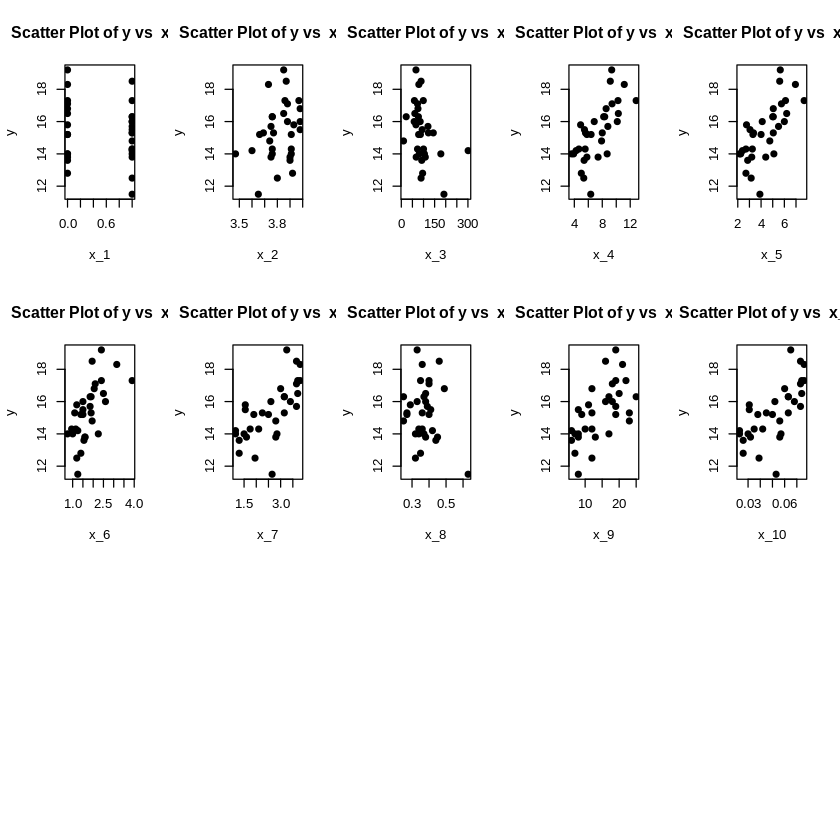

In [ ]:
par(mfrow = c(3,5))
for (col in colnames(DATA)) {
    if (col != "y" && is.numeric(DATA[[col]])) {  # Ensure it's numeric
      plot(DATA[[col]], DATA$y,
           main = paste("Scatter Plot of y vs ",col),
           xlab = col, ylab = "y",
           col = "black", pch = 19)
    }
  }
  par(mfrow = c(3,5))

Histograms

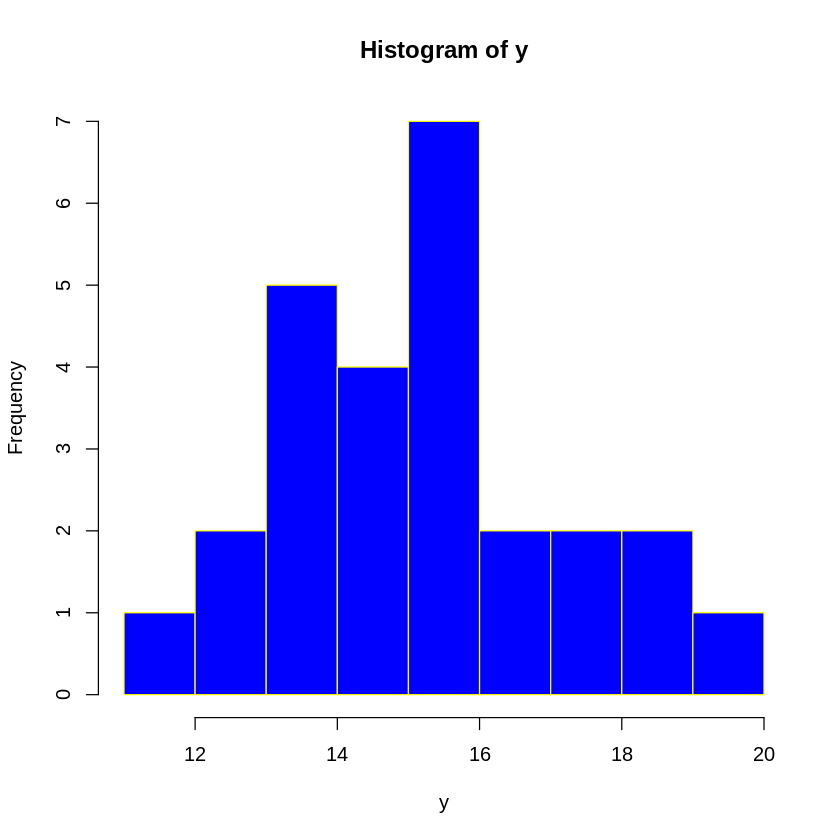

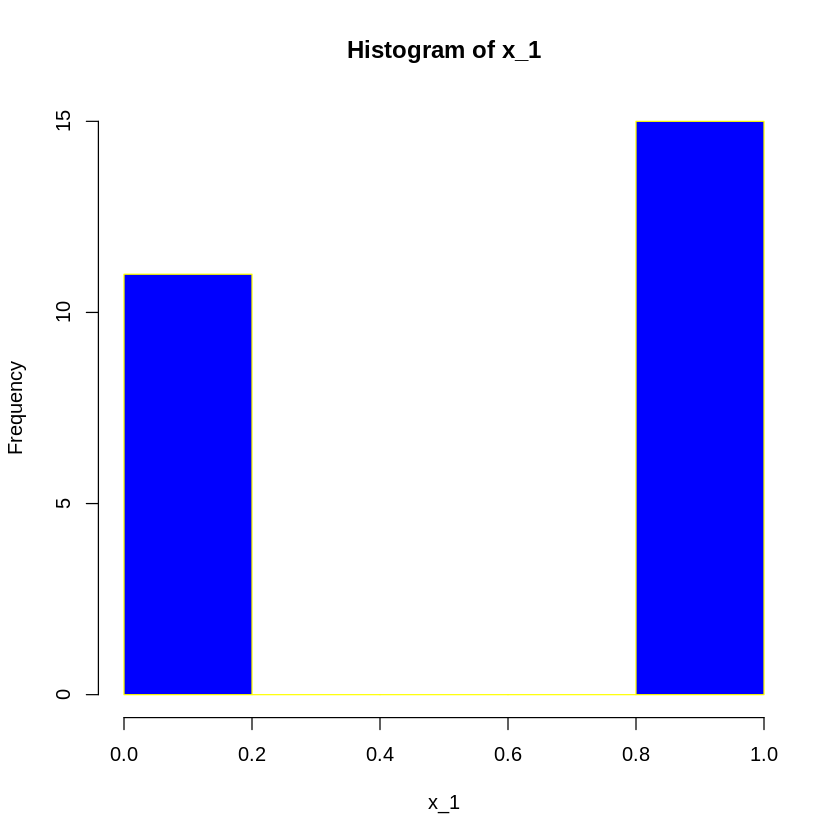

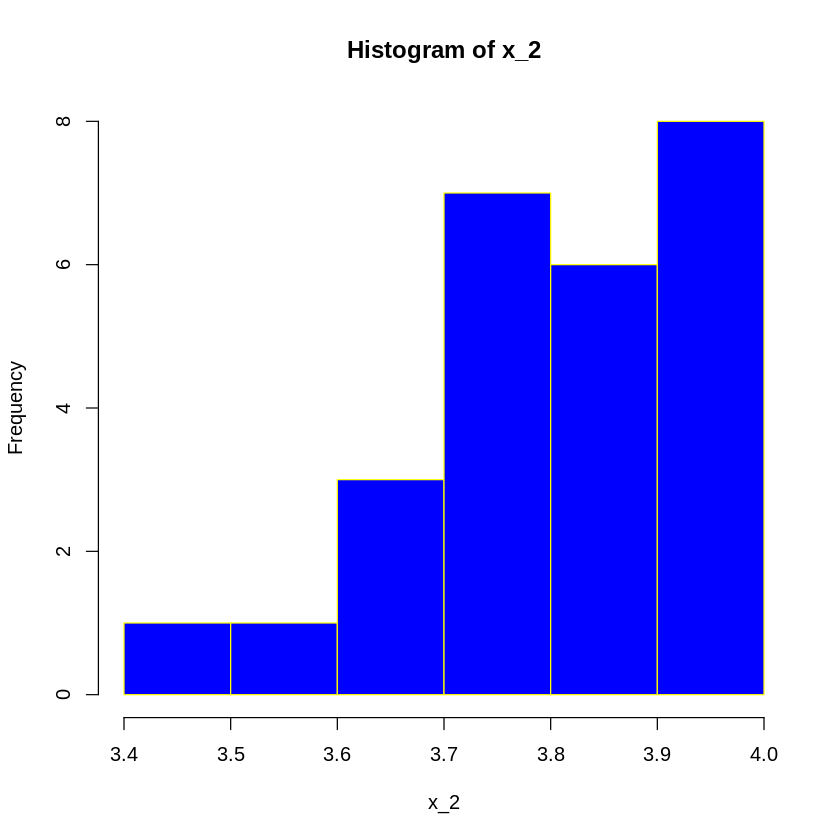

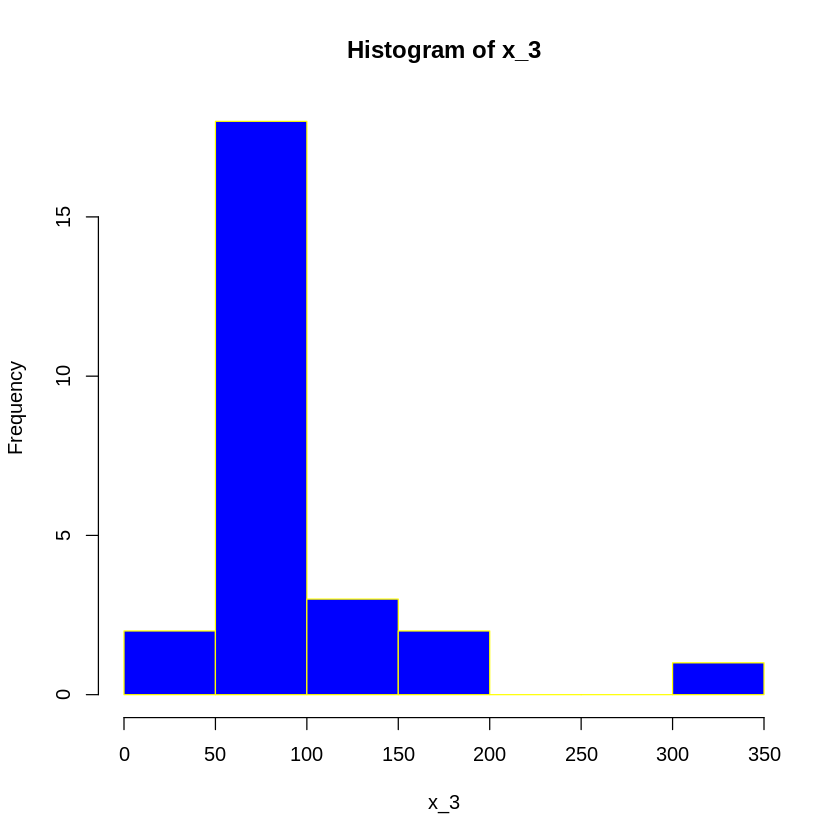

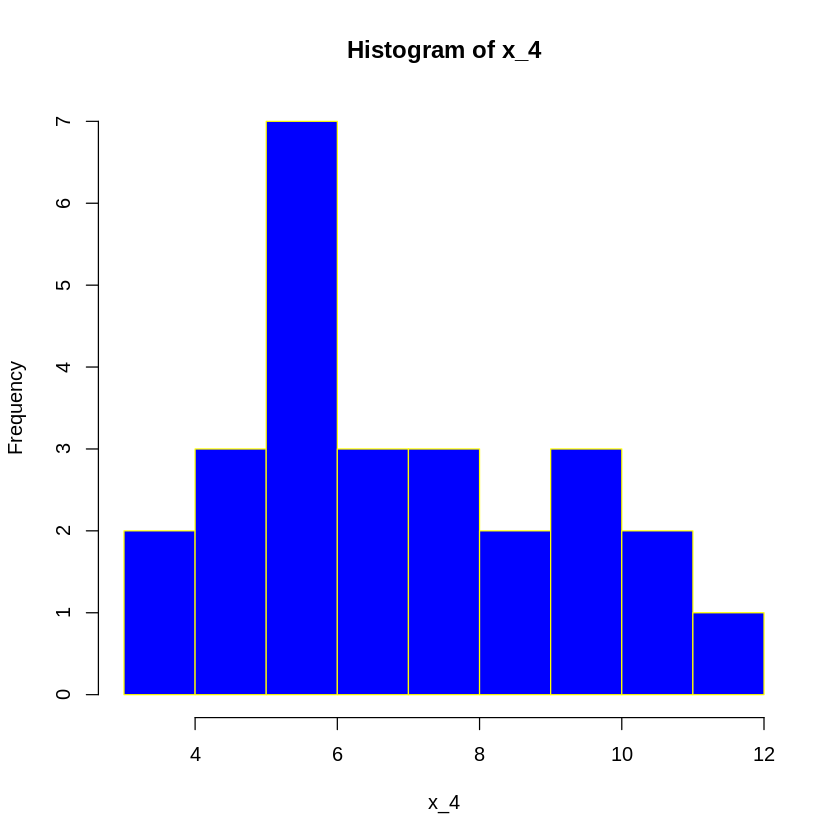

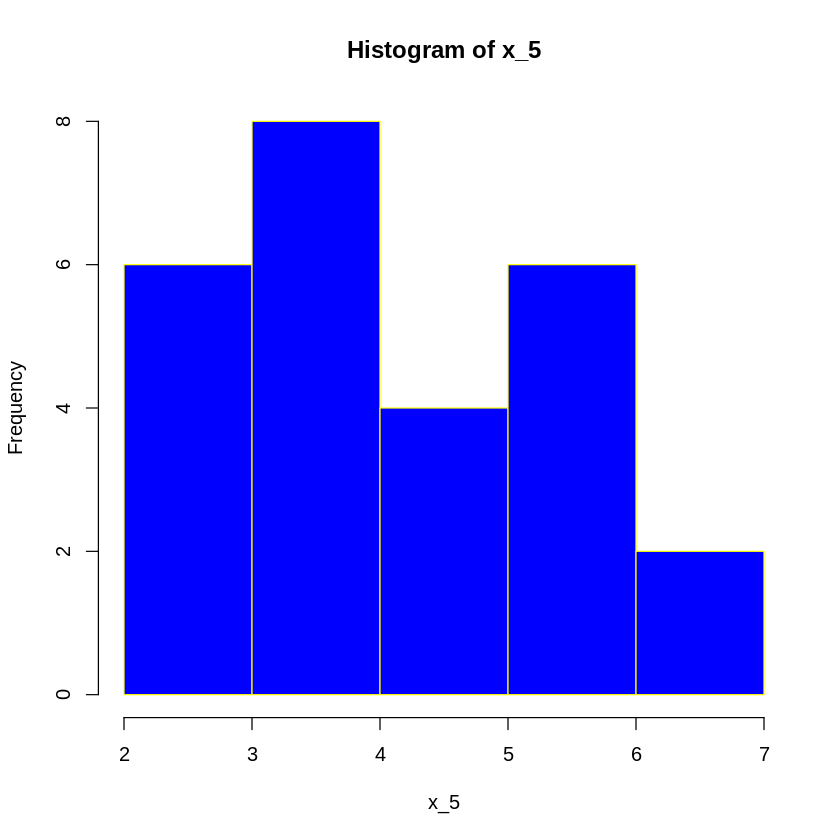

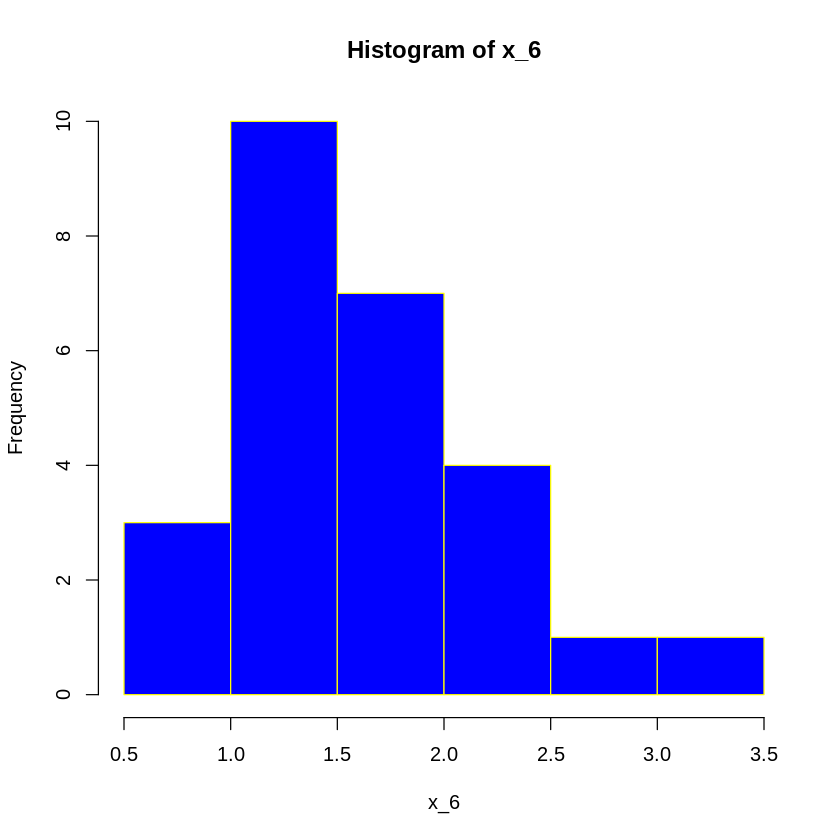

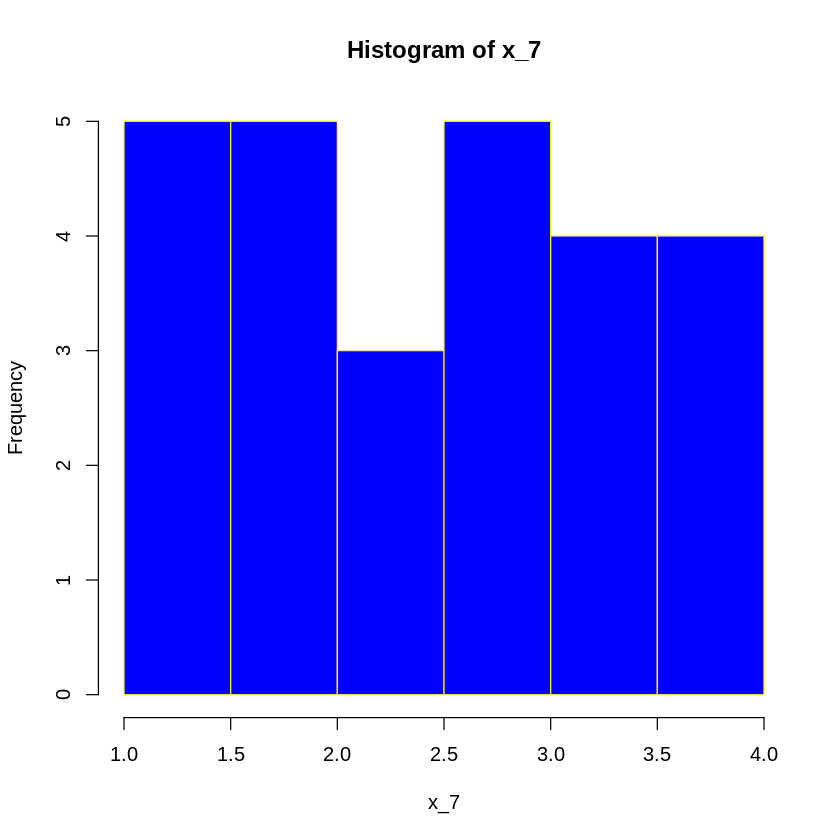

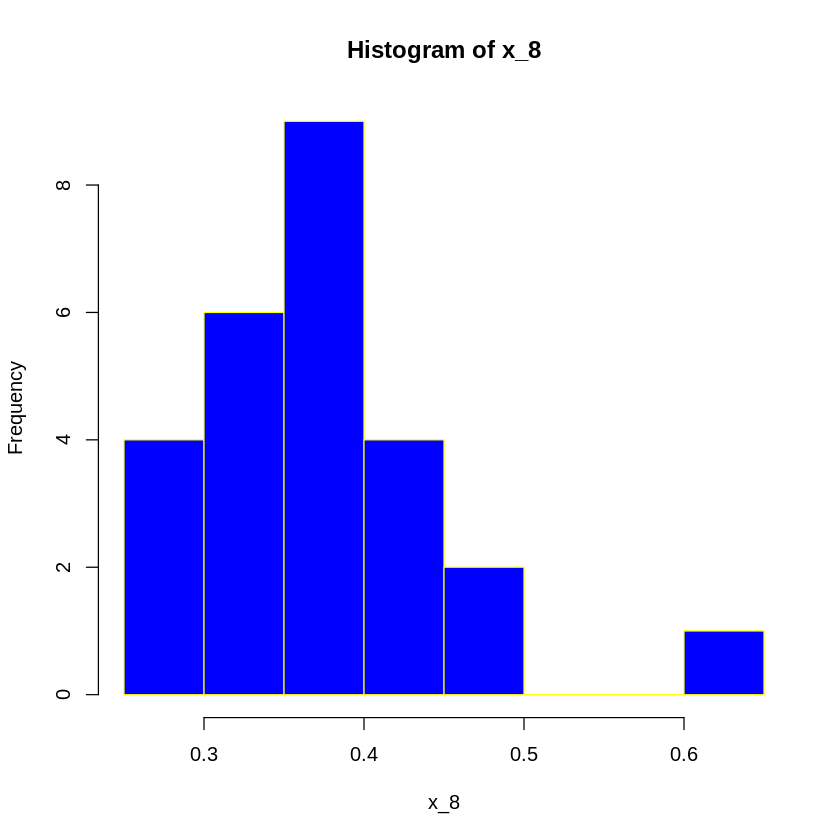

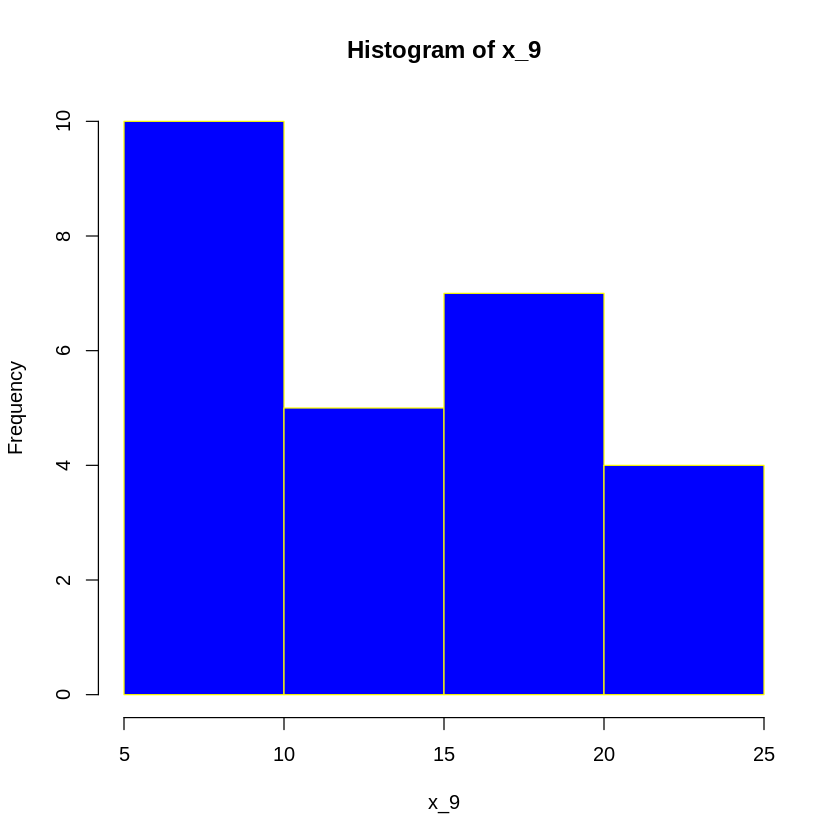

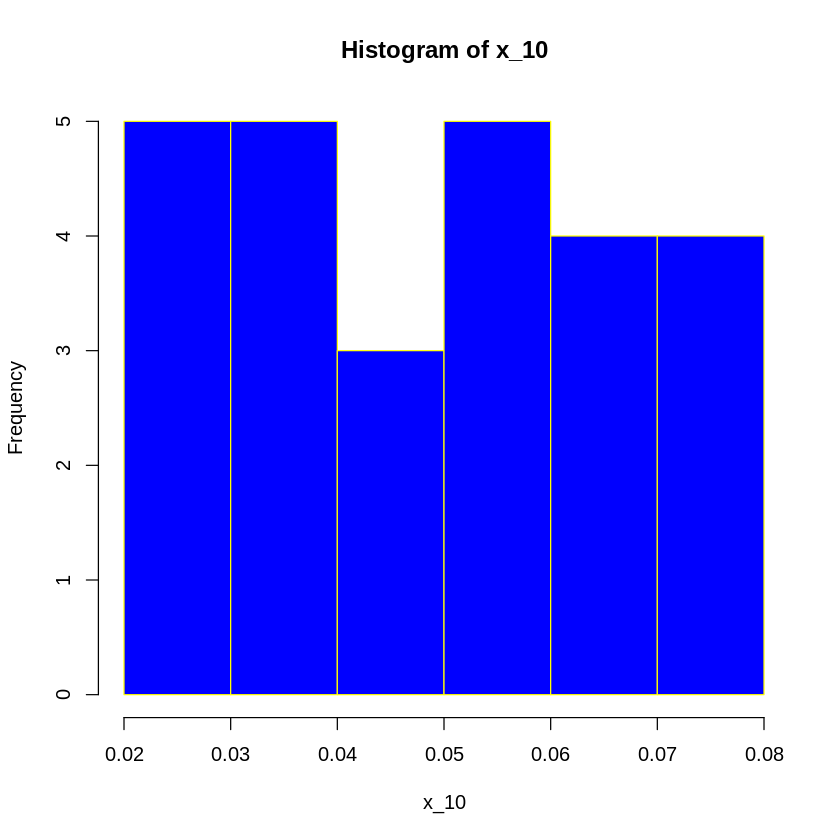

In [ ]:
par(mfrow = c(1,1))
for (col in colnames(DATA)) {
  hist(train_data[[col]],
       main = paste("Histogram of", col),
       xlab = col,
       col = "blue",
       border = "yellow")
}
par(mfrow = c(1, 1))

Boxplots

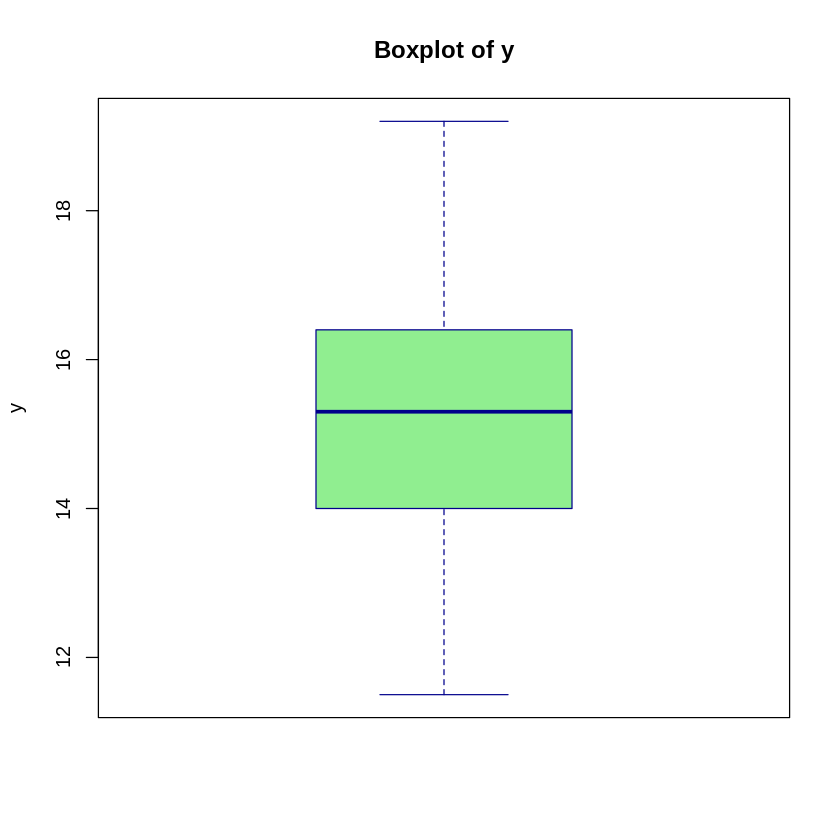

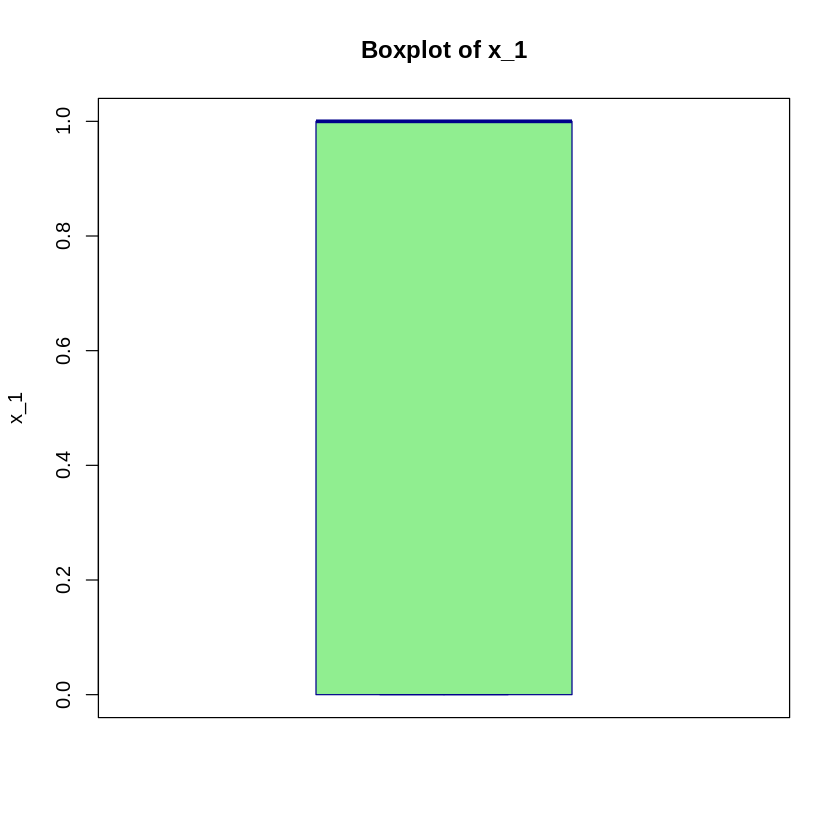

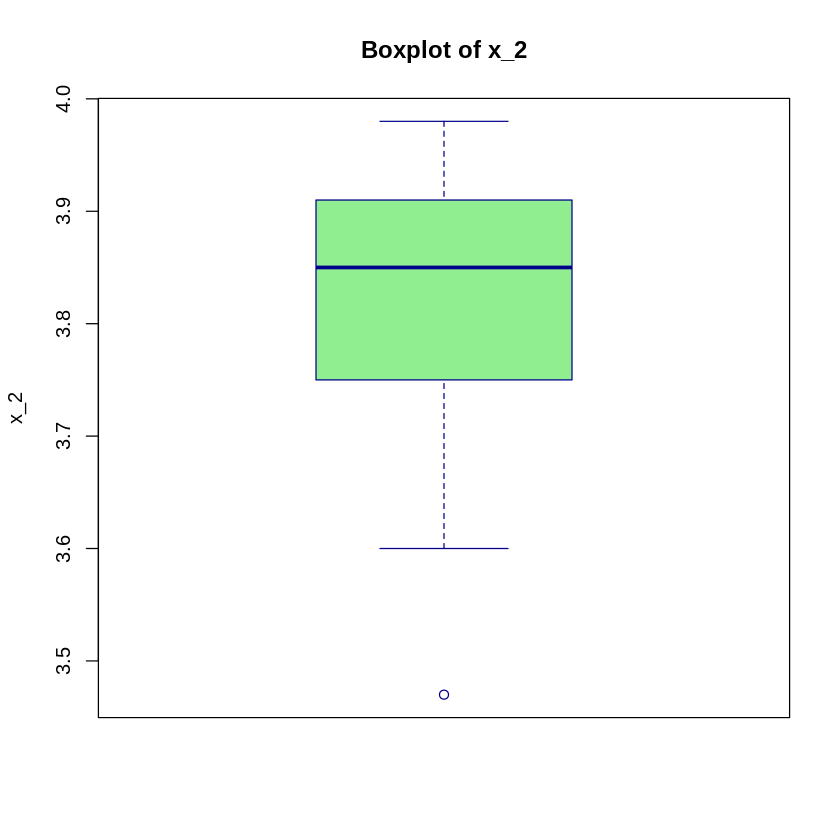

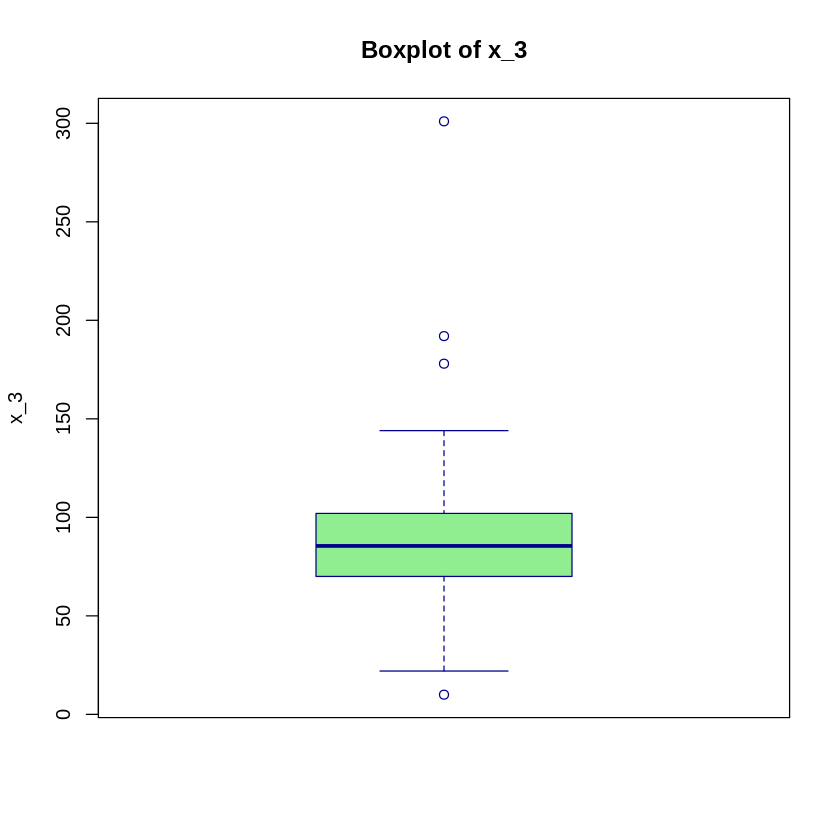

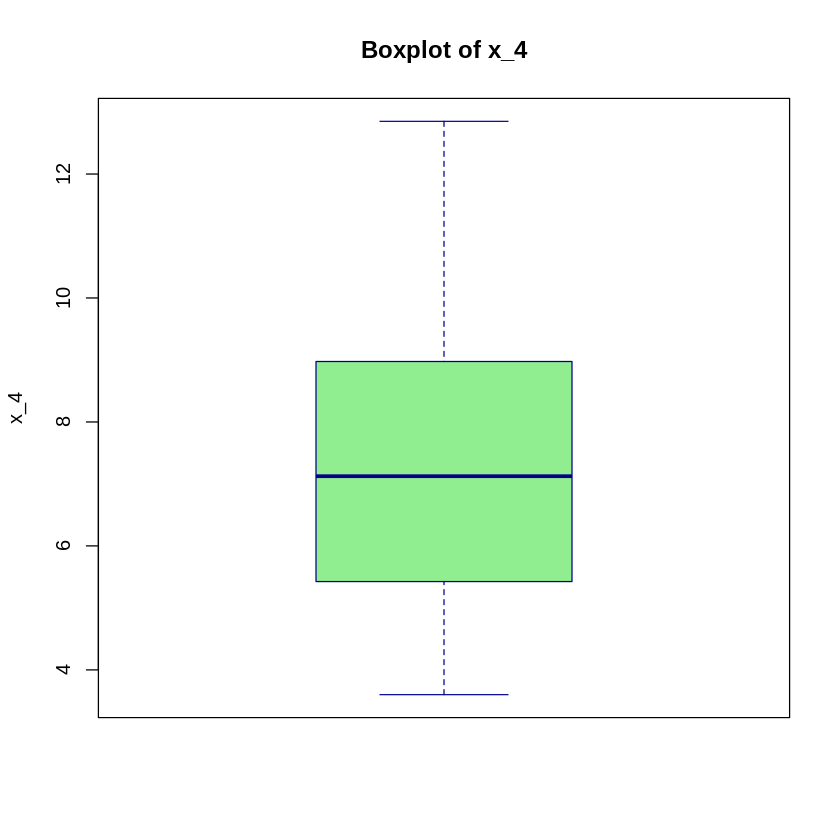

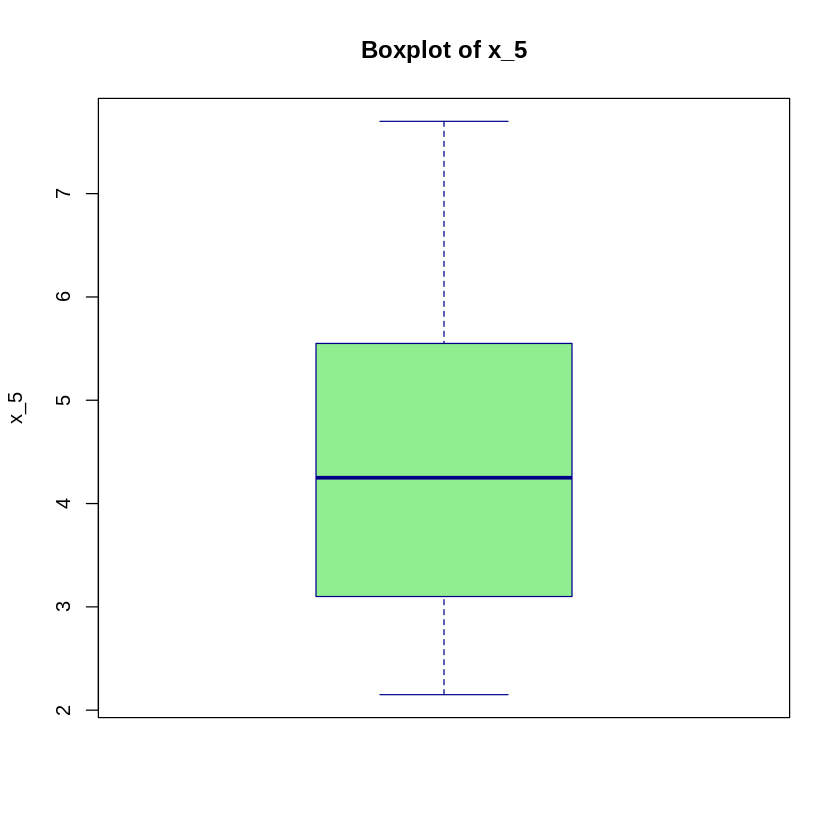

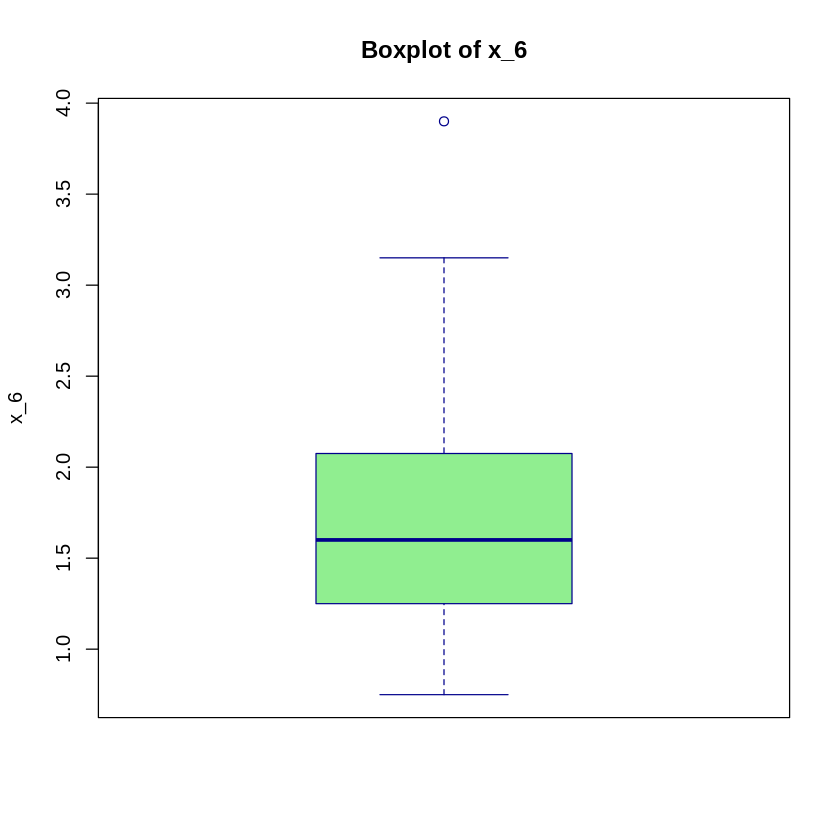

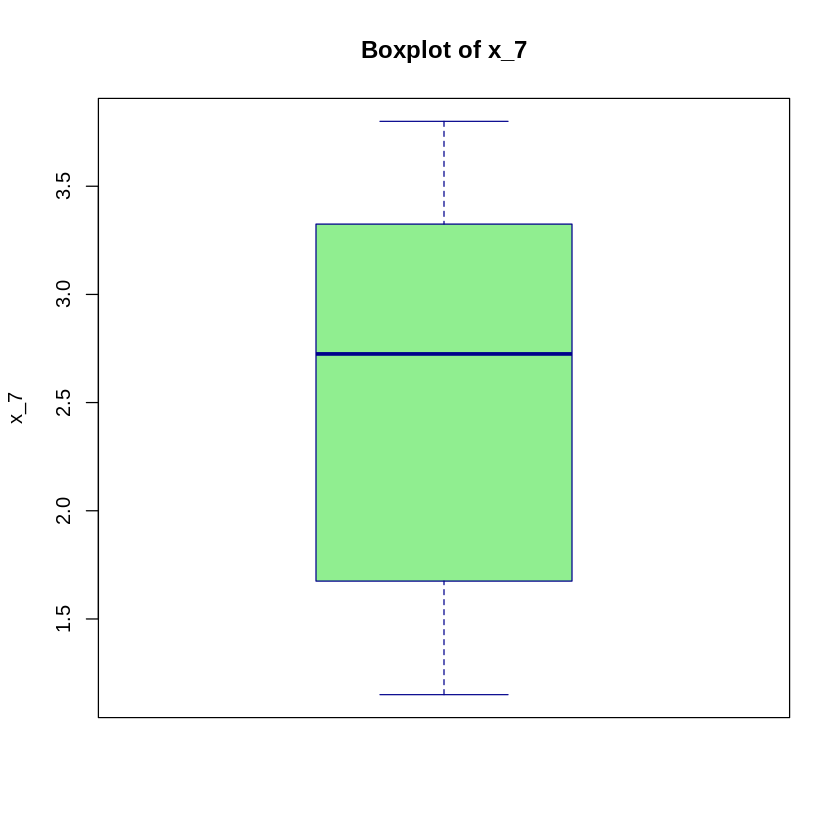

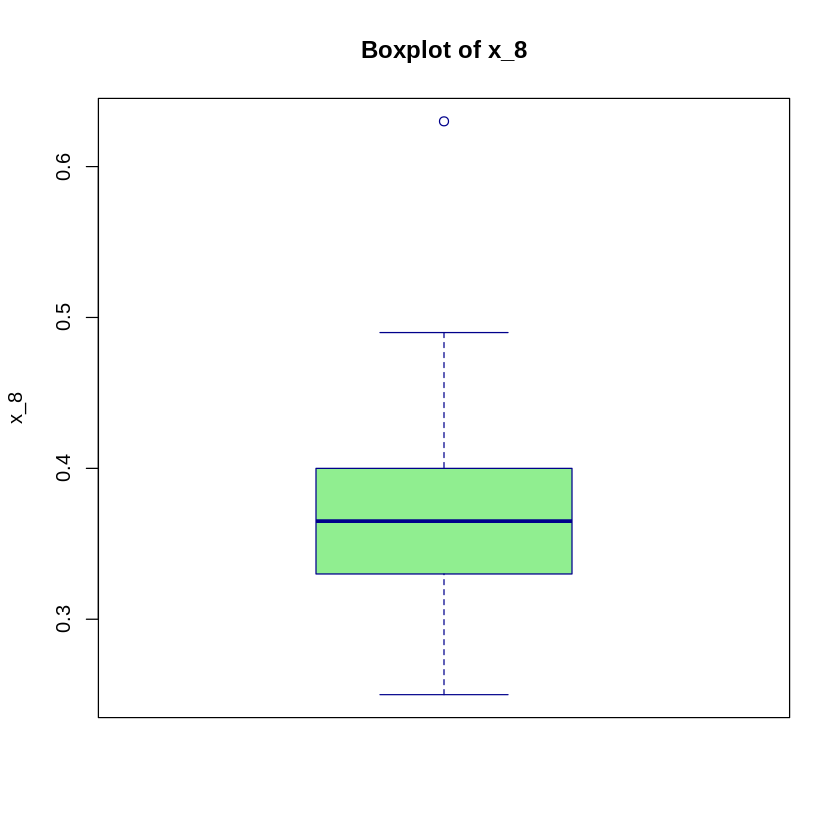

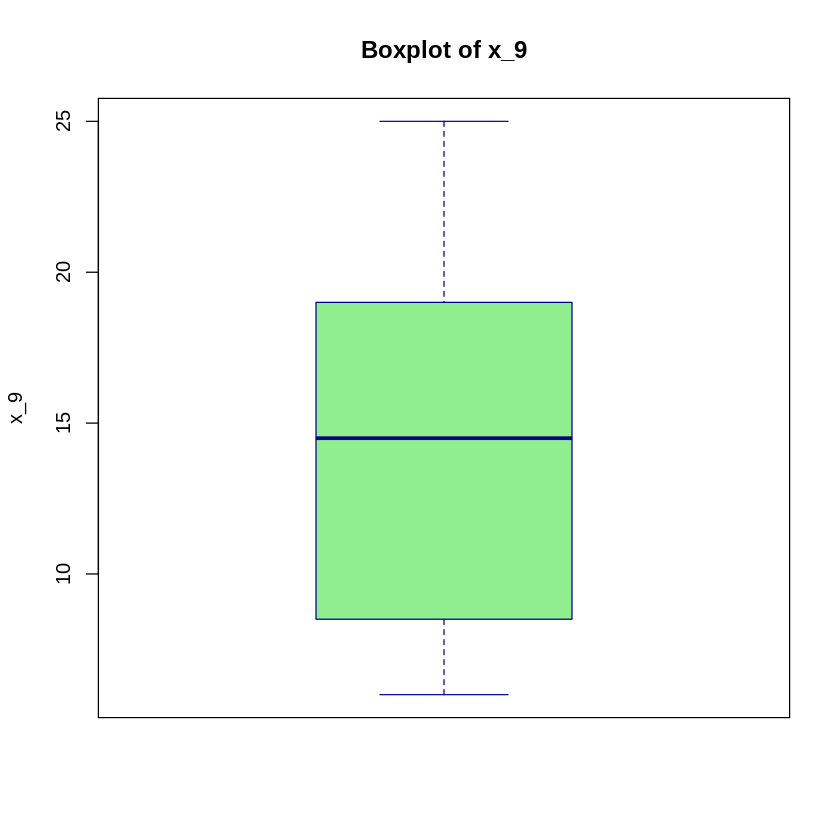

$x_2
[1] 10

$x_3
[1] 10 25 28 32

$x_6
[1] 4

$x_8
[1] 32



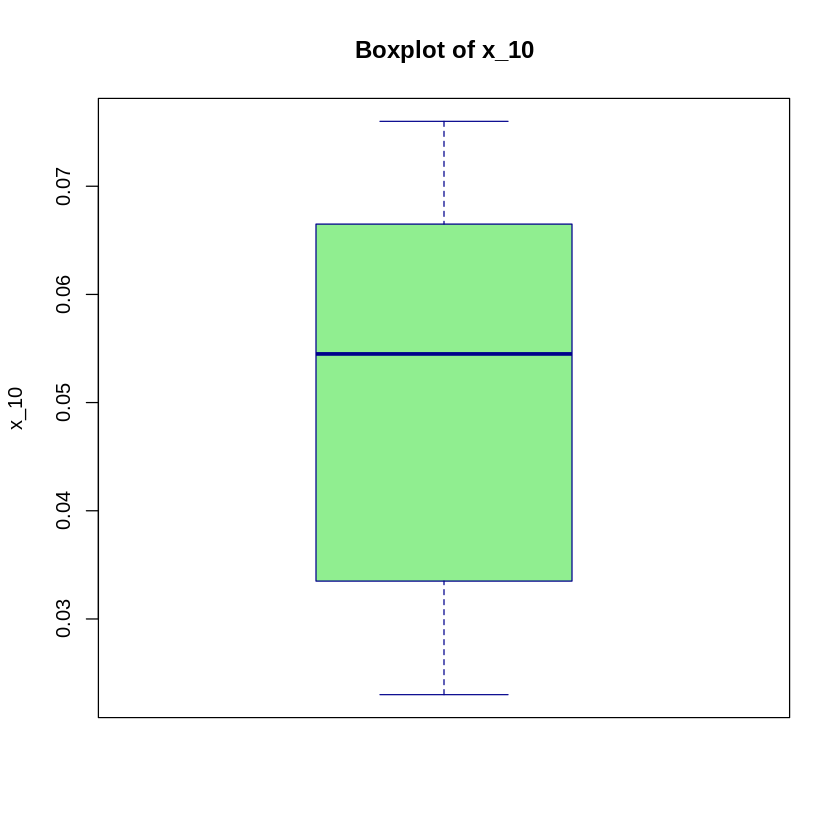

In [ ]:
par(mfrow = c(1, 1))  # Adjust based on the number of columns

# Create an empty list to store outlier indices for each column
outlier_list <- list()

# Loop through each column in train_data
for (col in colnames(DATA)) {
  # Check if the column is numeric before plotting
  if (is.numeric(DATA[[col]])) {

    column_data <- DATA[[col]]

    # Identify outliers using boxplot.stats
    outliers <- boxplot.stats(column_data)$out

    # Save indices of outliers
    if (length(outliers) > 0) {
      outlier_indices <- which(column_data %in% outliers)
      outlier_list[[col]] <- outlier_indices  # Store by column name
    }

    # Draw boxplot
    boxplot(column_data, main = paste("Boxplot of", col),
            col = "light green", ylab = col, border = "darkblue")
  }
}

# Reset plot layout to default
par(mfrow = c(1, 1))

# Print outlier indices list
print(outlier_list)



```
# This is formatted as code
```

Correlation Matrix

In [ ]:
Cor1 = cor(DATA)

Cor1

,y,x_1,x_2,x_3,x_4,x_5,x_6,x_7,x_8,x_9,x_10
y,1.0000000,-0.169878902,0.27747066,-0.3758899,0.701838522,0.707654712,0.65117305,0.68129132,-0.168180167,0.6170341,0.68129132
x_1,-0.1698789,1.000000000,-0.08880617,0.1150501,-0.008509266,0.012577406,-0.16389528,0.14334447,0.050018542,0.1637408,0.14334447
x_2,0.2774707,-0.088806174,1.00000000,-0.5820282,0.213164035,0.152141791,0.22044010,0.08631043,0.095509243,-0.0489386,0.08631043
x_3,-0.3758899,0.115050136,-0.58202821,1.0000000,-0.391465151,-0.370944023,-0.32542171,-0.36902794,0.404545811,-0.4959928,-0.36902794
x_4,0.7018385,-0.008509266,0.21316403,-0.3914652,1.000000000,0.995666429,0.94541703,0.93671923,0.015519116,0.7968608,0.93671923
x_5,0.7076547,0.012577406,0.15214179,-0.3709440,0.995666429,1.000000000,0.92529036,0.95892682,0.003091977,0.8260006,0.95892682
x_6,0.6511730,-0.163895282,0.22044010,-0.3254217,0.945417026,0.925290358,1.00000000,0.77970743,-0.042853322,0.6905468,0.77970743
x_7,0.6812913,0.143344473,0.08631043,-0.3690279,0.936719226,0.958926821,0.77970743,1.00000000,0.037155356,0.8472281,1.00000000
x_8,-0.1681802,0.050018542,0.09550924,0.4045458,0.015519116,0.003091977,-0.04285332,0.03715536,1.000000000,-0.4558050,0.03715536
x_9,0.6170341,0.163740803,-0.04893860,-0.4959928,0.796860805,0.826000635,0.69054681,0.84722807,-0.455804998,1.0000000,0.84722807


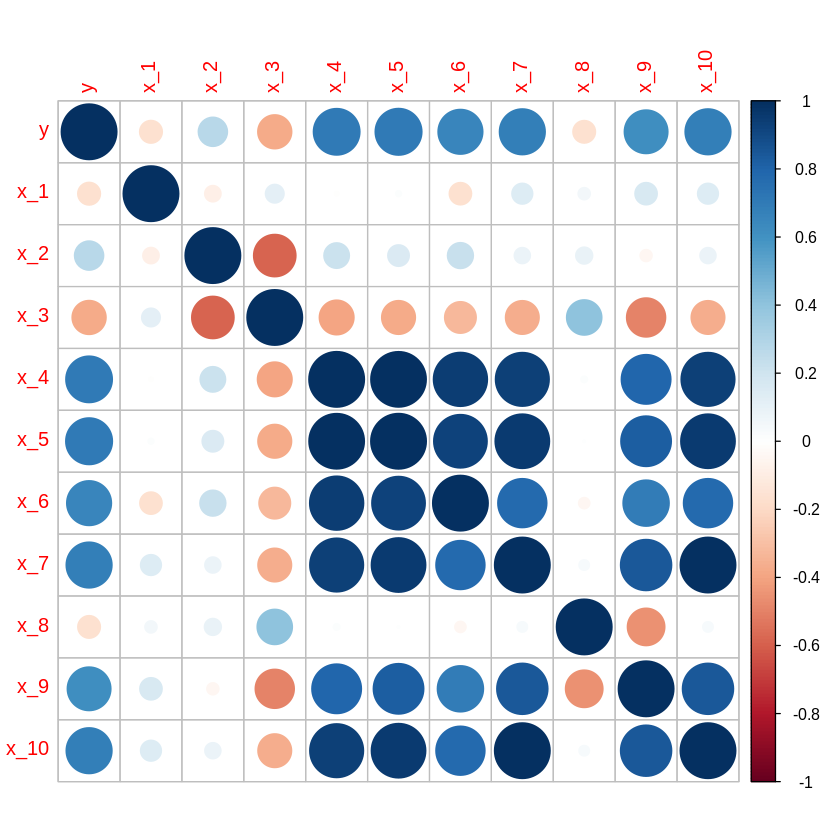

In [ ]:
corrplot(Cor1)

#Spiliting dataset into Train and Test

Split the datset in train:test based on Boolean vector

In [ ]:
set.seed(1)
sample <- sample(c(TRUE, FALSE), nrow(DATA), replace=TRUE, prob=c(0.8, 0.2))
train_data <- DATA[sample, ]
test_data <- DATA[!sample, ]

print(train_data)
print(length(train_data))
cat("Train set dimensions:", dim(train_data), "\n")
cat("Test set dimensions:", dim(test_data), "\n")

      y x_1  x_2 x_3   x_4  x_5  x_6  x_7  x_8 x_9  x_10
1  19.2   0 3.85  66  9.35 5.65 2.40 3.25 0.33  19 0.065
2  18.3   0 3.73  79 11.15 6.95 3.15 3.80 0.36  21 0.076
3  17.1   0 3.88  73  9.40 5.75 2.10 3.65 0.40  18 0.073
5  16.8   0 3.98  75  8.55 5.05 2.05 3.00 0.49  12 0.060
8  15.2   0 3.66  86  6.40 4.00 1.50 2.50 0.27  19 0.050
9  15.2   0 3.91  78  5.80 3.30 1.40 1.90 0.40   9 0.038
10 14.0   0 3.47 178  3.60 2.25 0.75 1.50 0.37   8 0.030
11 14.0   0 3.91  81  3.90 2.15 1.00 1.15 0.32   7 0.023
12 13.8   0 3.75 108  5.80 3.20 1.60 1.60 0.38   8 0.032
13 13.6   0 3.90  92  5.40 2.85 1.55 1.30 0.44   6 0.026
14 12.8   0 3.92  96  5.00 2.70 1.40 1.30 0.35   7 0.026
15 18.5   1 3.87  89  9.15 5.60 1.95 3.65 0.46  16 0.073
16 17.3   1 3.97  59 10.25 6.10 2.40 3.70 0.40  19 0.074
17 16.3   1 3.76  22  8.20 5.00 1.85 3.15 0.25  25 0.063
19 16.0   1 3.98  58 10.15 6.00 2.60 3.40 0.38  18 0.068
20 16.0   1 3.88  85  6.85 4.10 1.50 2.60 0.33  16 0.052
22 15.5   1 3.98  94  5.45 3.05

In [ ]:
print(test_data)

      y x_1  x_2 x_3   x_4  x_5  x_6  x_7  x_8 x_9  x_10
4  17.3   0 3.86  99 12.85 7.70 3.90 3.80 0.35  22 0.076
6  16.5   0 3.85  61 10.30 6.20 2.50 3.70 0.38  20 0.074
7  15.8   0 3.93  66  4.90 2.75 1.20 1.55 0.29  11 0.031
18 16.3   1 3.76  77  8.35 5.05 1.90 3.15 0.37  17 0.063
21 15.7   1 3.75 120  8.80 5.50 1.85 3.65 0.39  19 0.073
29 14.0   1 3.76 104  8.70 5.10 2.25 2.85 0.34  17 0.057


EDA of train_data

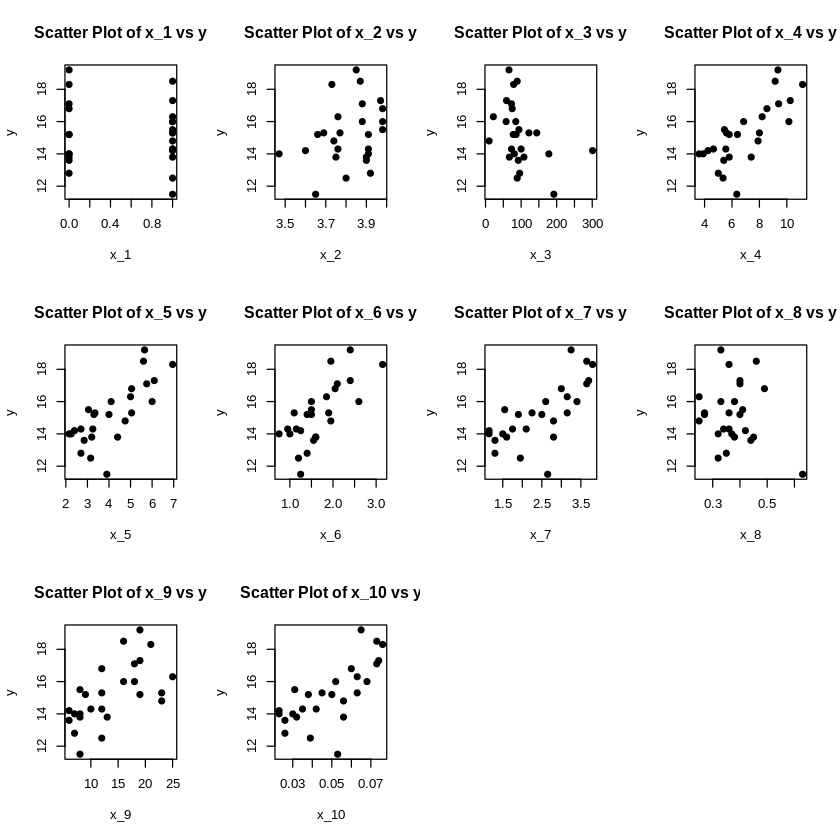

In [ ]:
par(mfrow = c(3,4))
for (col in colnames(train_data)) {
    if (col != "y" && is.numeric(train_data[[col]])) {  # Ensure it's numeric
      plot(train_data[[col]], train_data$y,
           main = paste("Scatter Plot of", col, "vs y"),
           xlab = col, ylab = "y",
           col = "black", pch = 19)
    }
  }
  par(mfrow = c(1, 1))

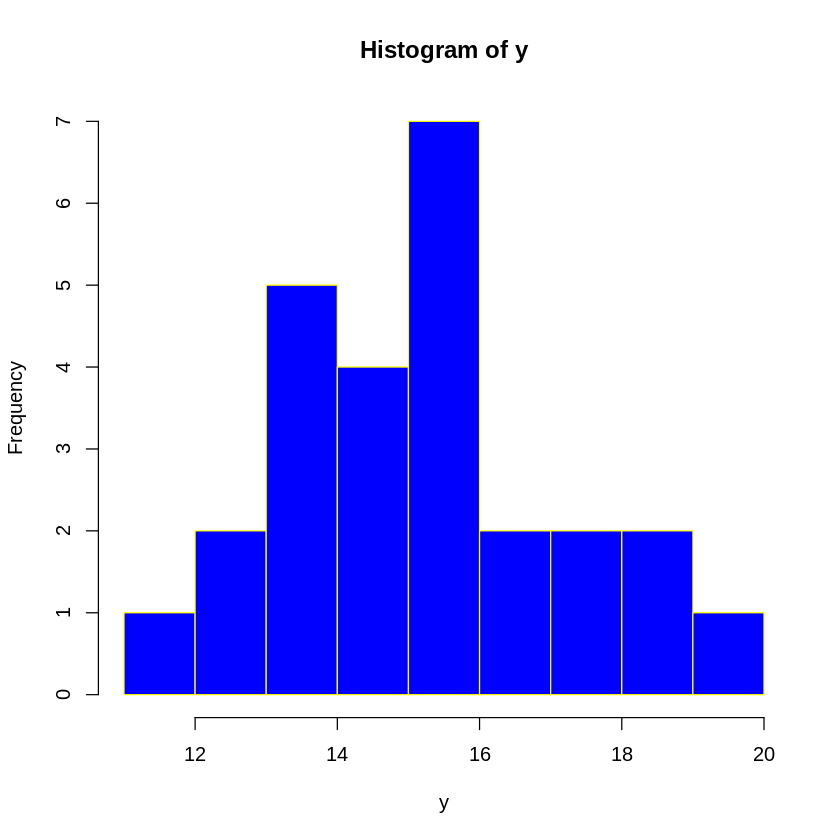

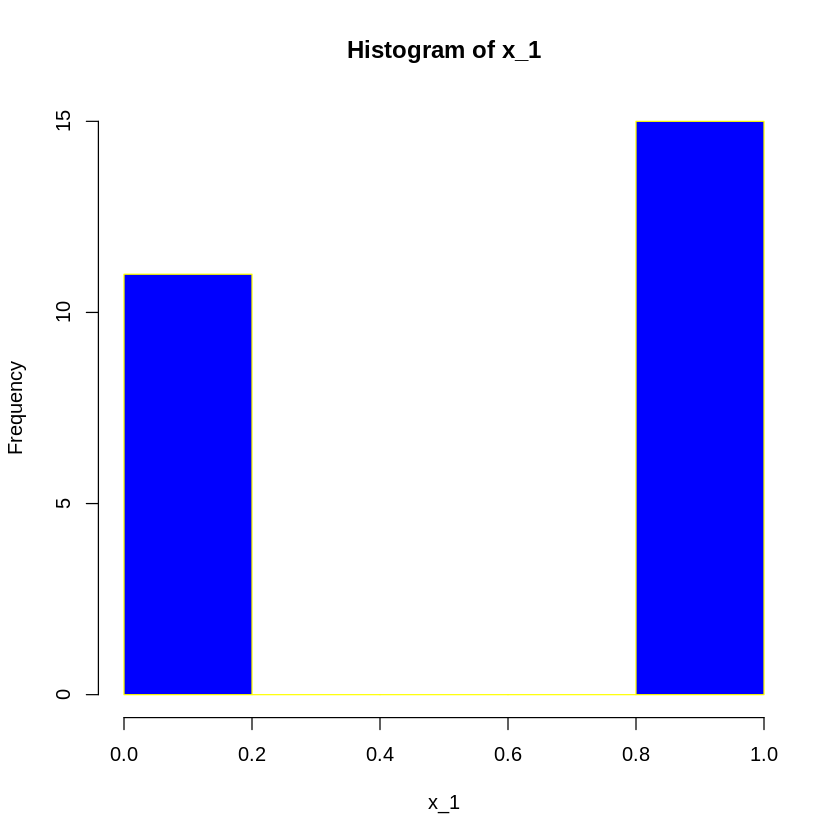

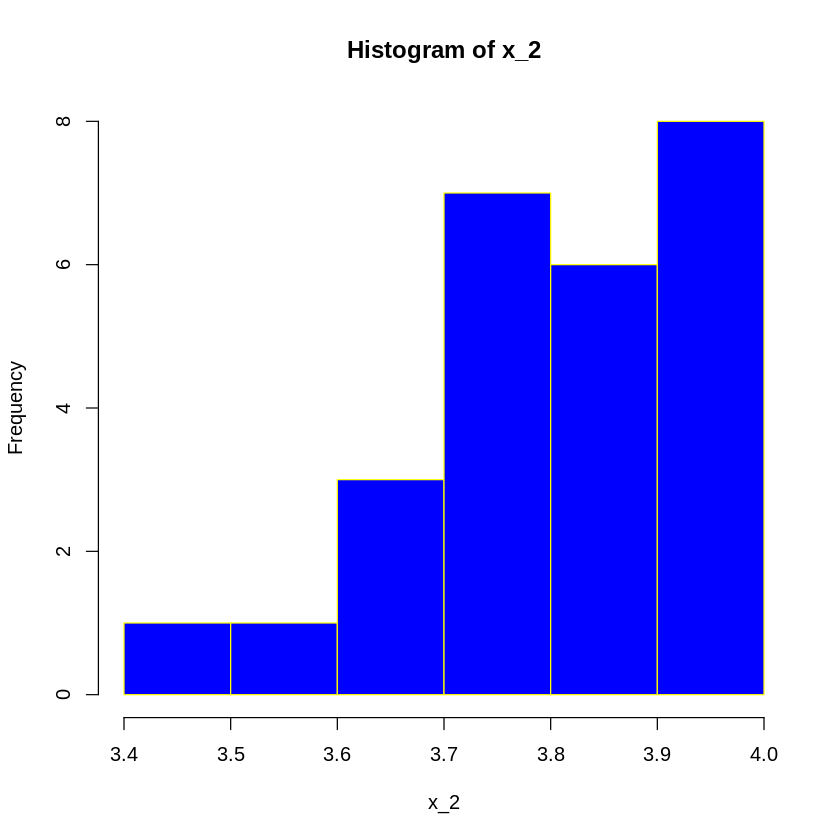

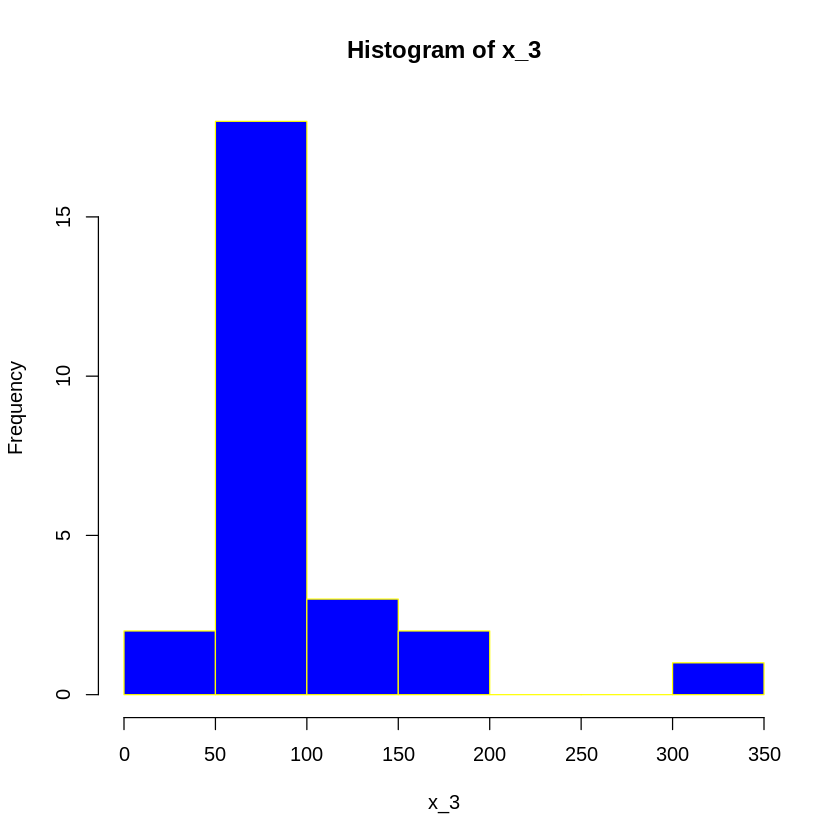

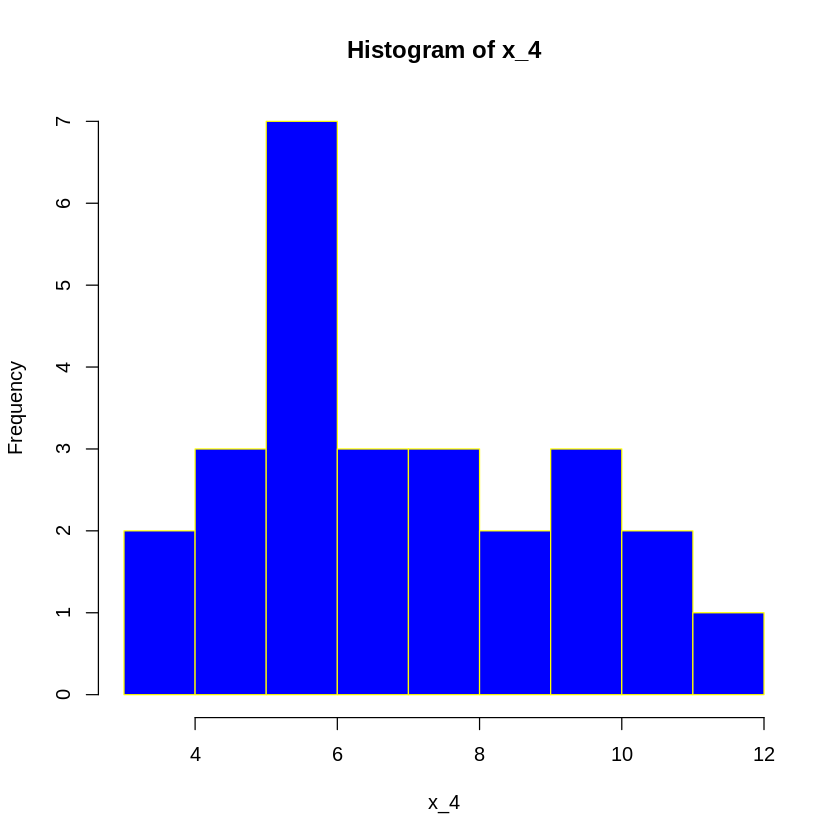

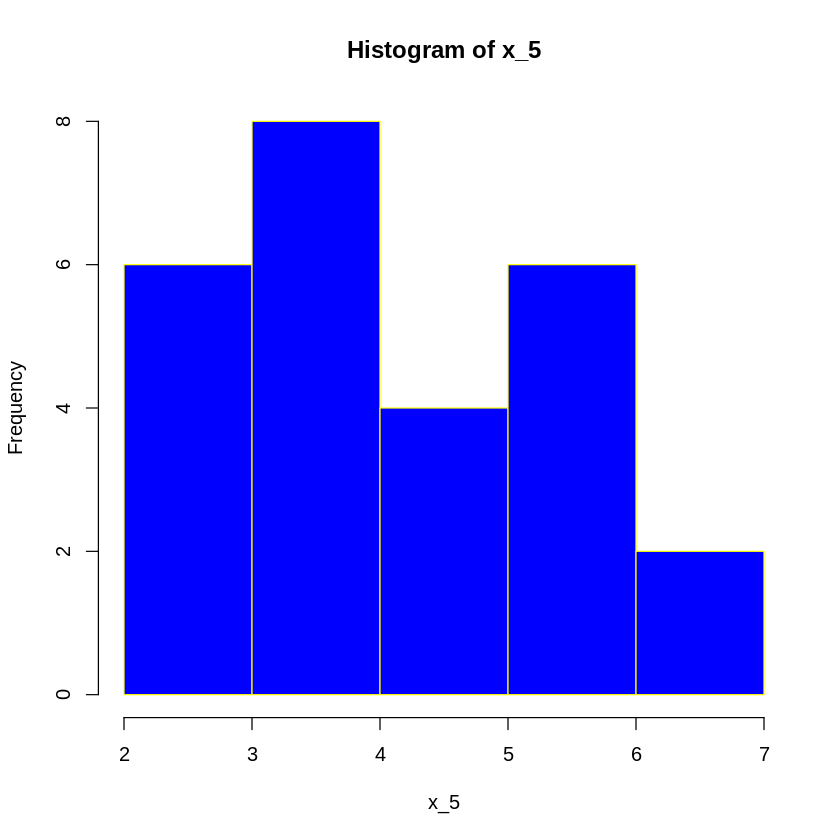

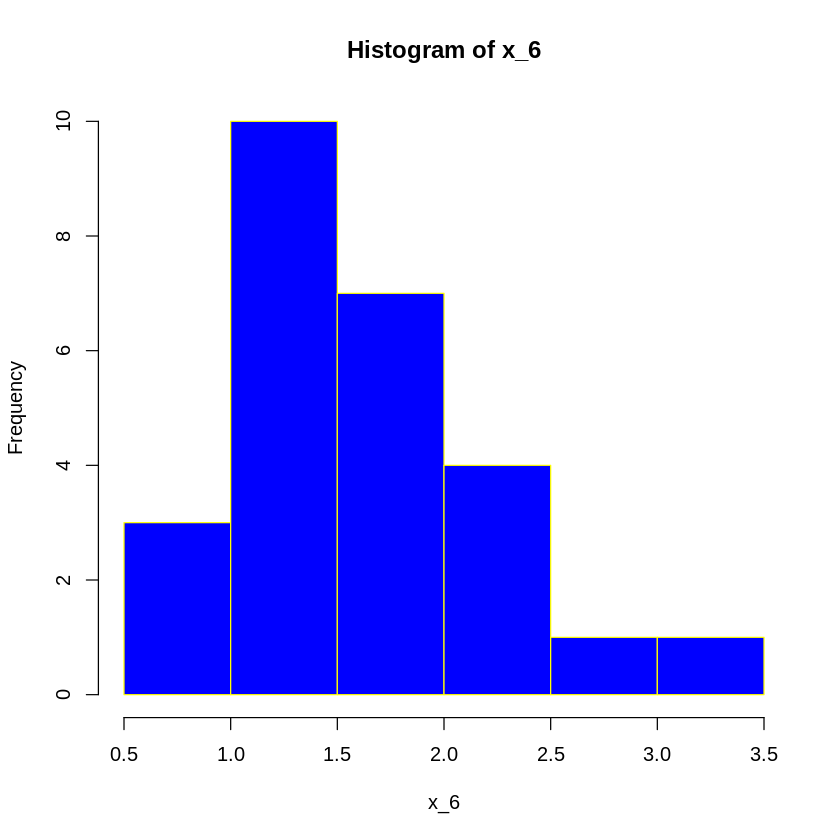

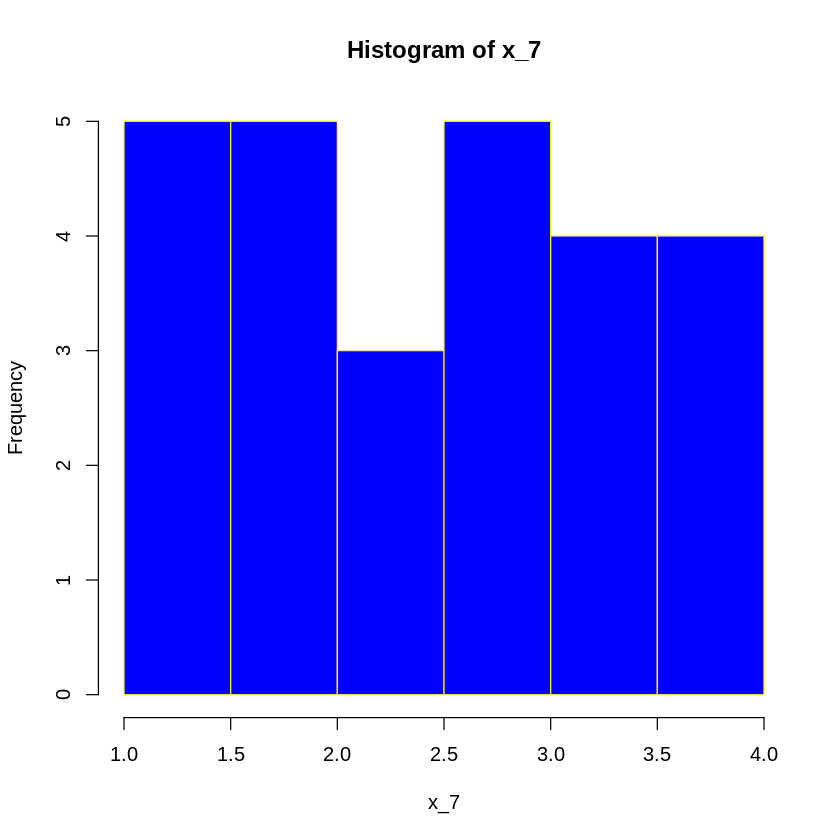

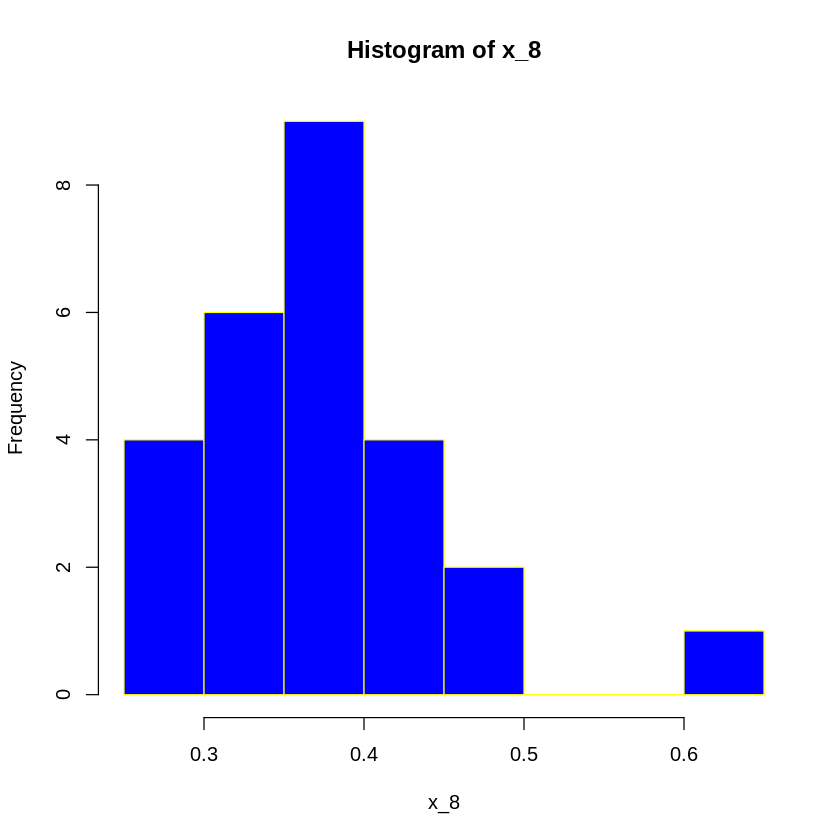

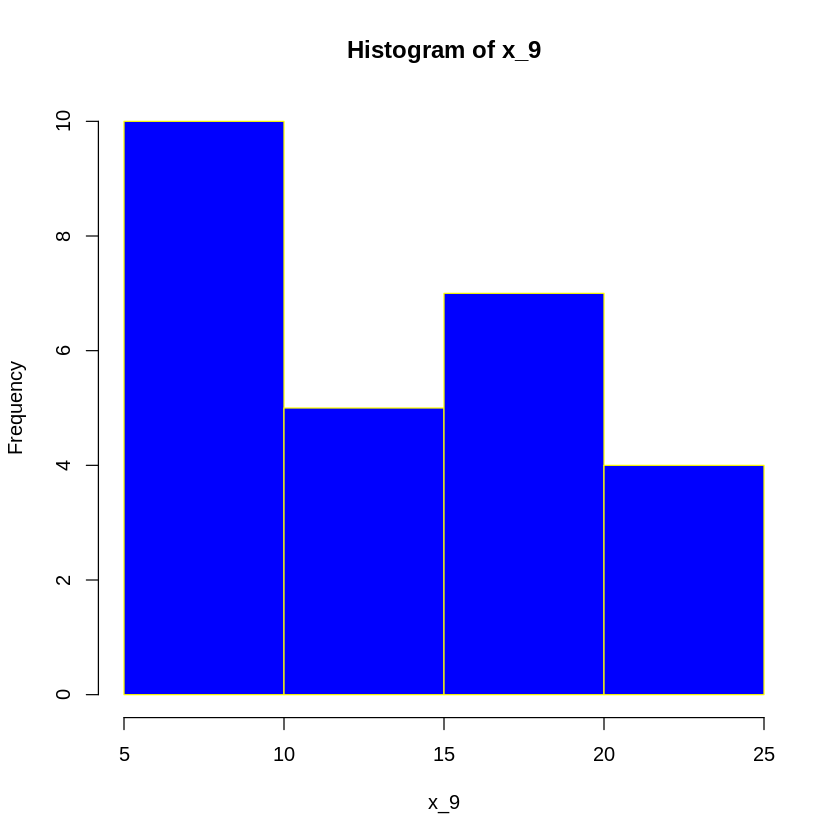

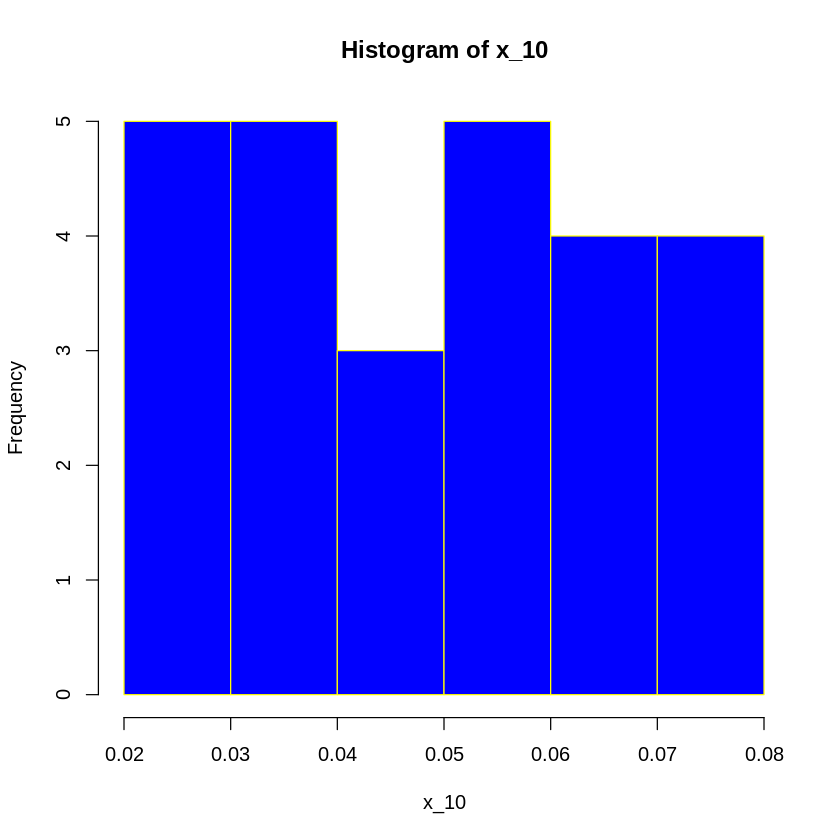

In [ ]:
par(mfrow = c(1,1))
for (col in colnames(train_data)) {
  hist(train_data[[col]],
       main = paste("Histogram of", col),
       xlab = col,
       col = "blue",
       border = "yellow")
}
par(mfrow = c(1, 1))

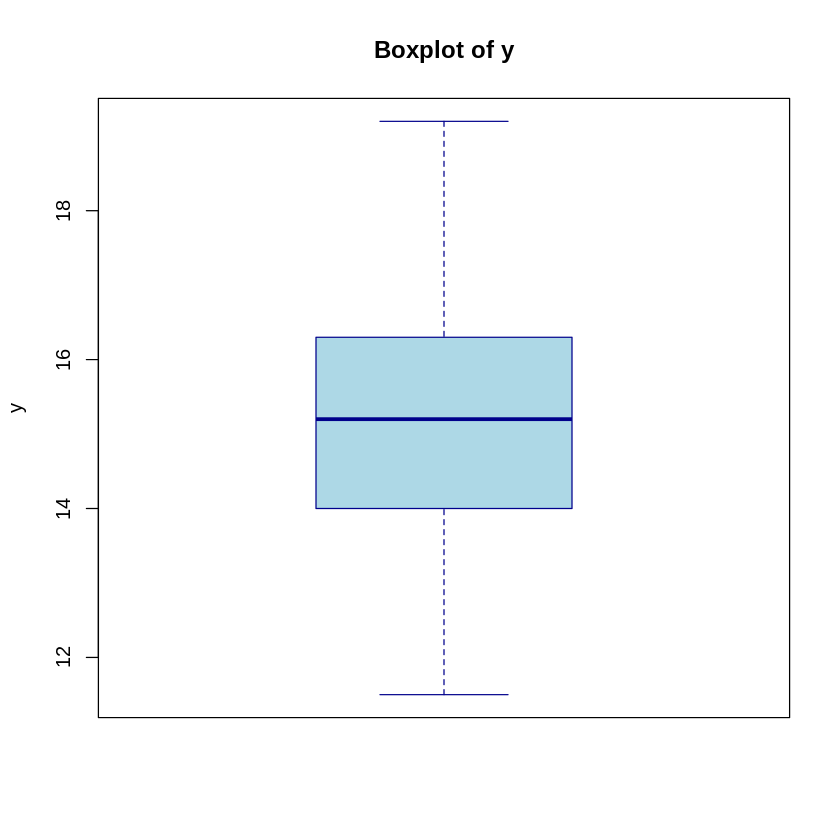

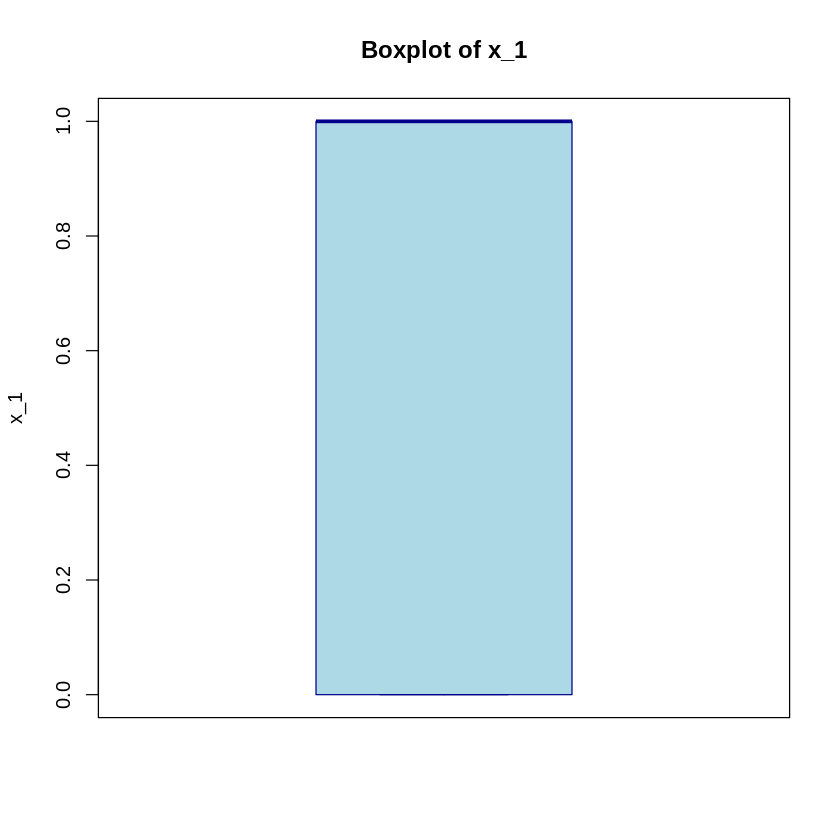

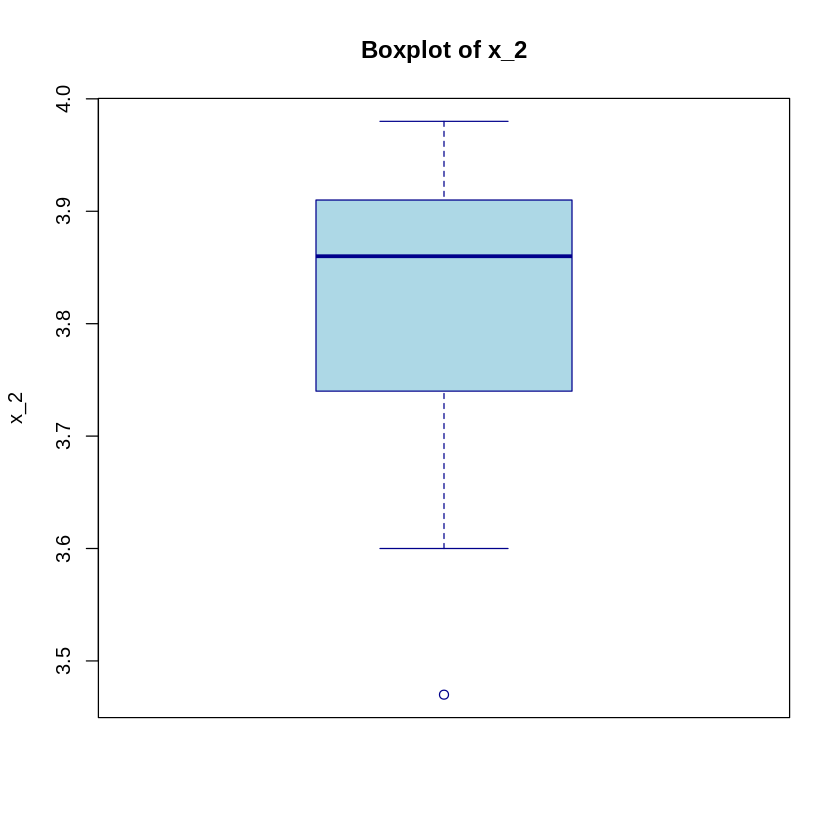

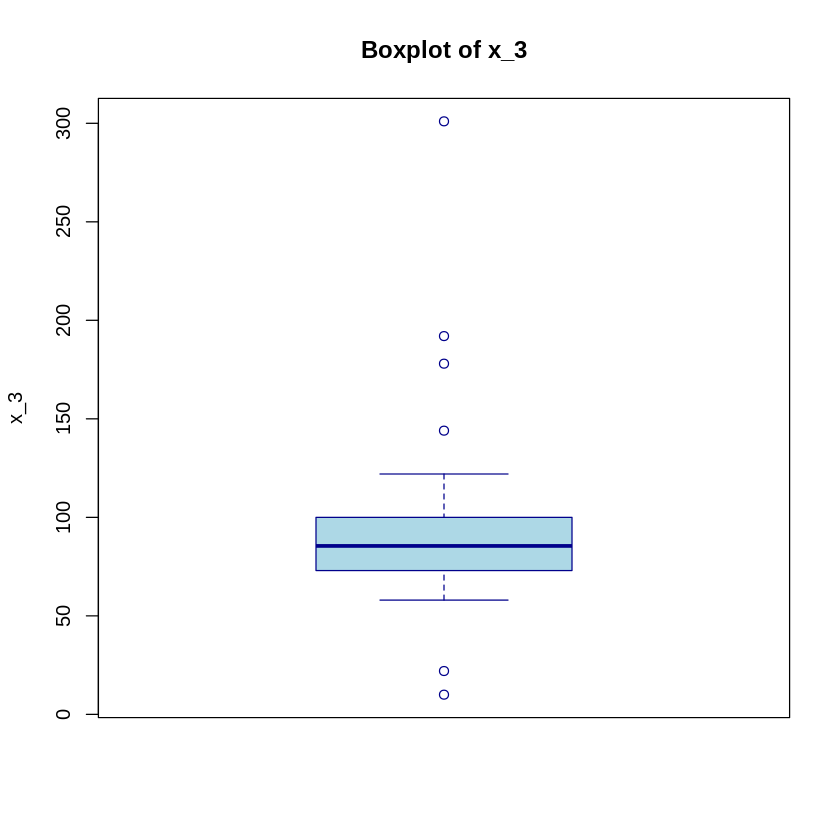

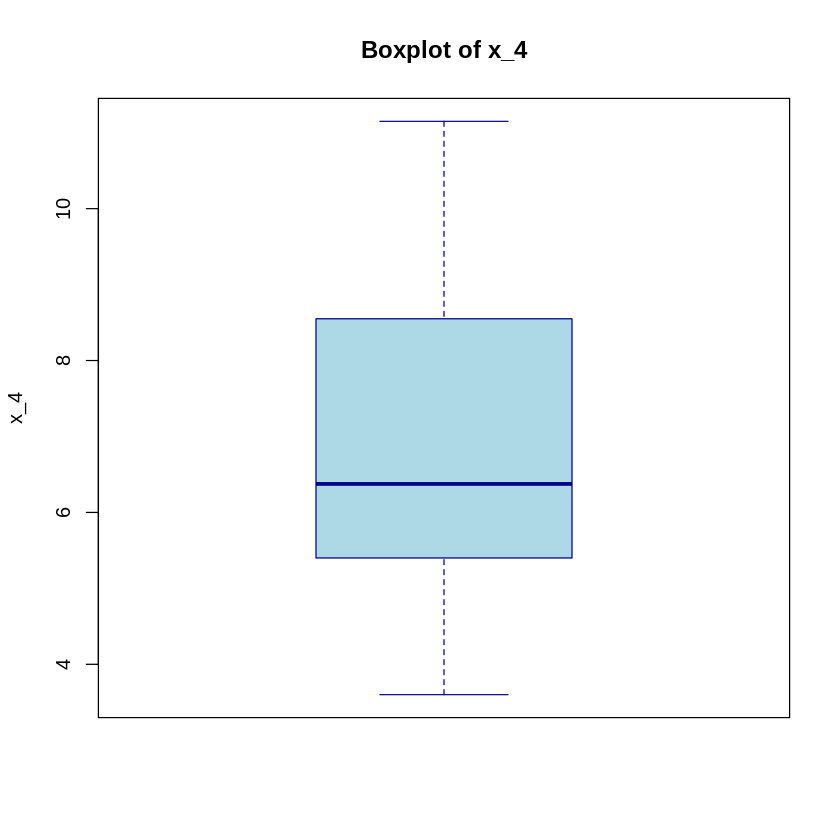

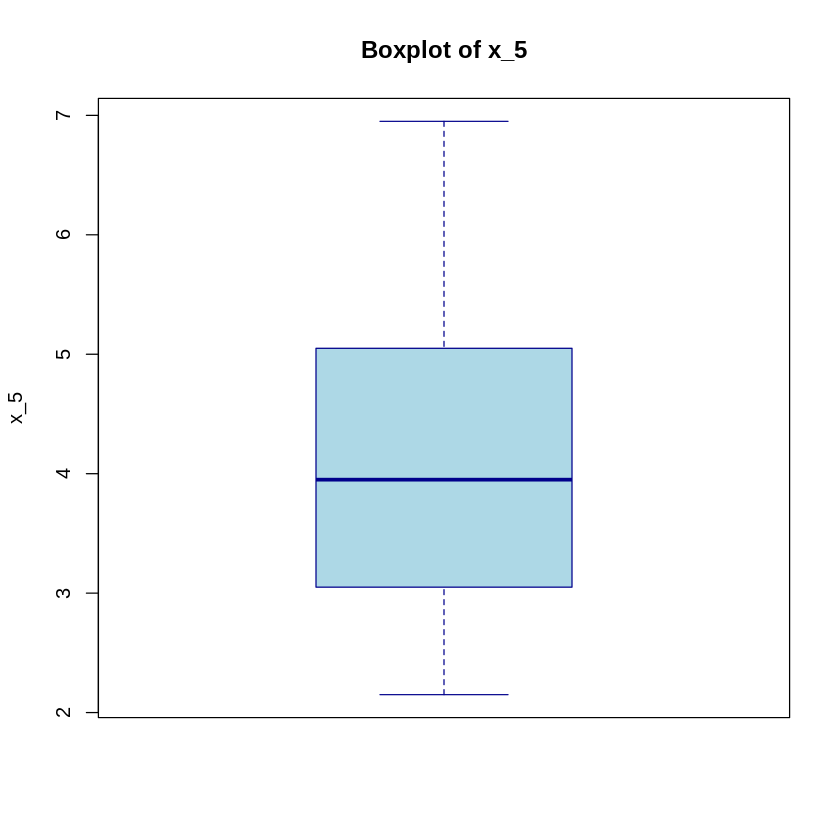

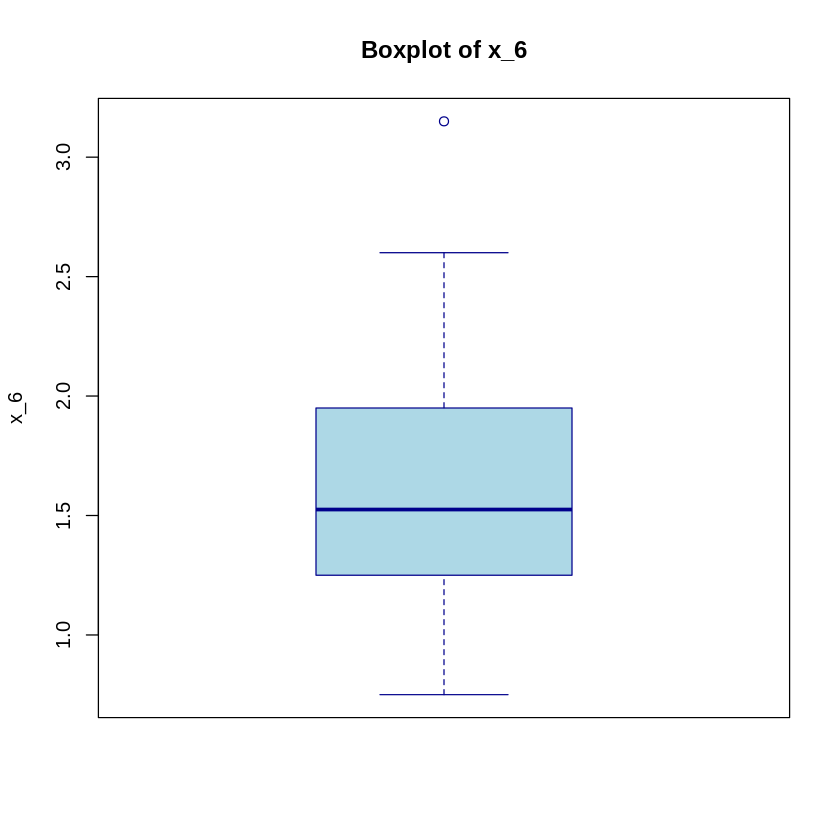

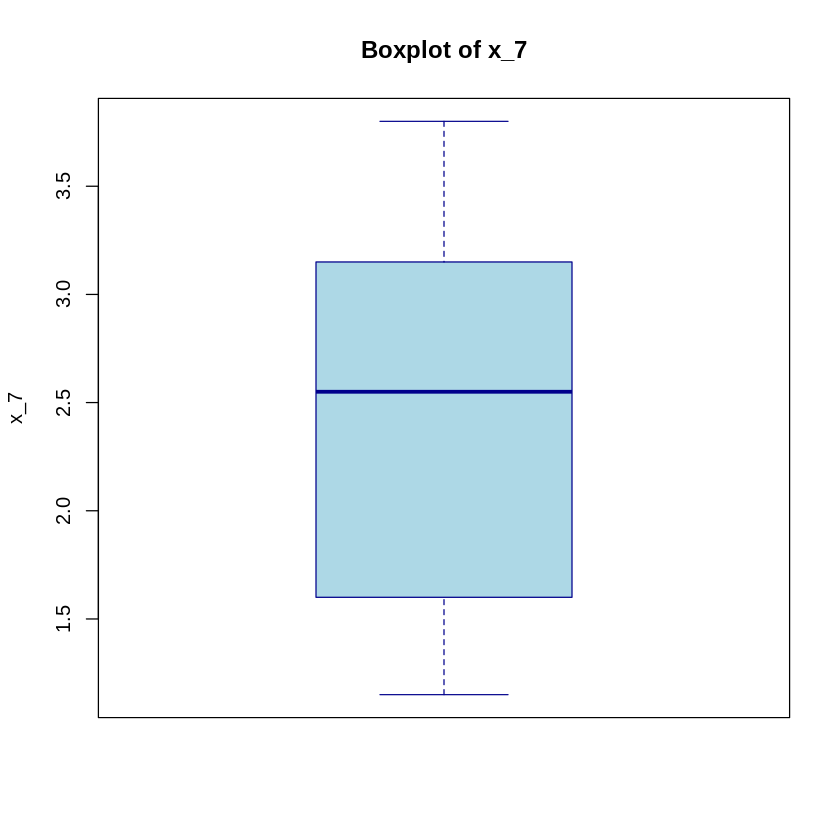

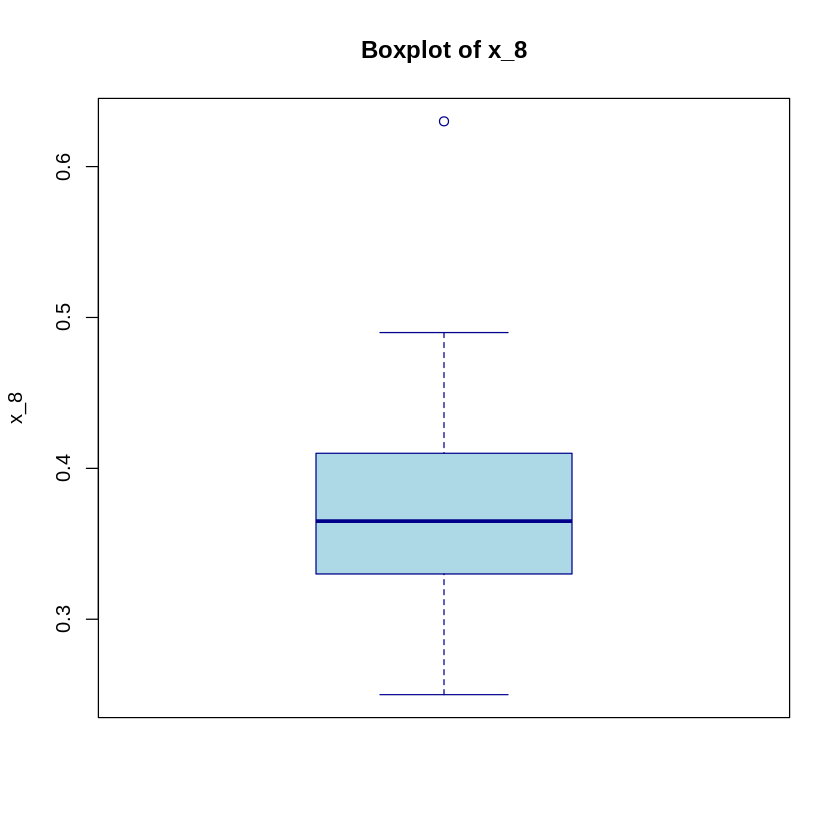

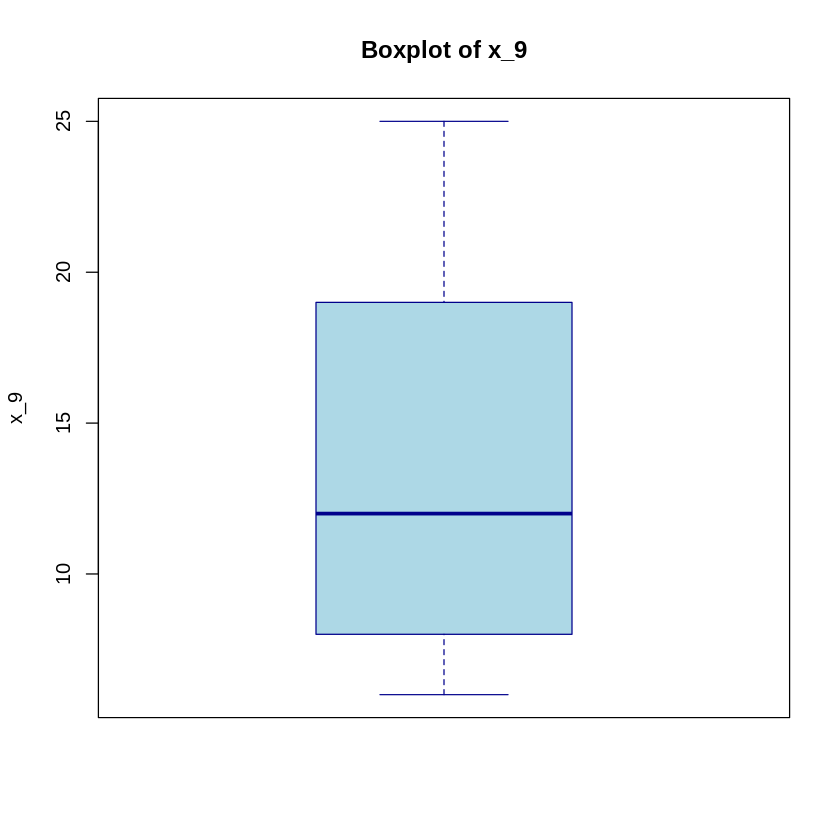

$x_2
[1] 7

$x_3
[1]  7 14 19 20 23 26

$x_6
[1] 2

$x_8
[1] 26



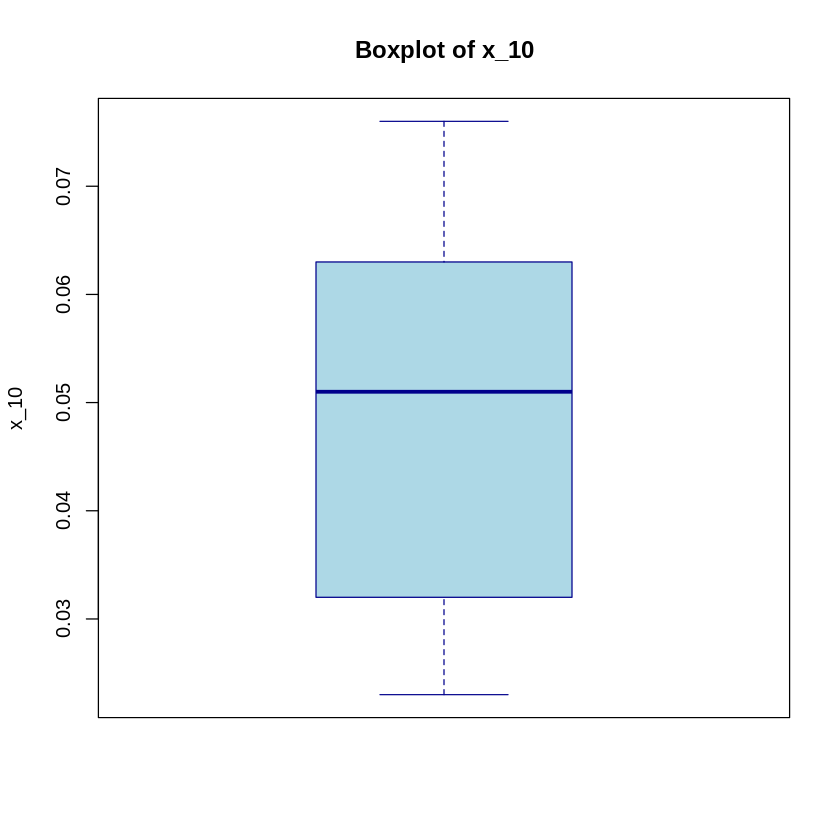

In [ ]:
par(mfrow = c(1, 1))  # Adjust based on the number of columns

# Create an empty list to store outlier indices for each column
outlier_list <- list()

# Loop through each column in train_data
for (col in colnames(train_data)) {
  # Check if the column is numeric before plotting
  if (is.numeric(train_data[[col]])) {

    column_data <- train_data[[col]]

    # Identify outliers using boxplot.stats
    outliers <- boxplot.stats(column_data)$out

    # Save indices of outliers
    if (length(outliers) > 0) {
      outlier_indices <- which(column_data %in% outliers)
      outlier_list[[col]] <- outlier_indices  # Store by column name
    }

    # Draw boxplot
    boxplot(column_data, main = paste("Boxplot of", col),
            col = "light blue", ylab = col, border = "darkblue")
  }
}

# Reset plot layout to default
par(mfrow = c(1, 1))

# Print outlier indices list
print(outlier_list)



```
# This is formatted as code
```

Correlation Matrix

In [ ]:
Cor2 = cor(train_data)
Cor3 =cor(test_data)

Drpping outliers based on IQR method

In [ ]:
# Assume train_data and outlier_list are already defined
all_outliers <- unique(unlist(outlier_list))
train_data_removedOutliers <- train_data[-all_outliers, ]

# Initialize list to store remaining outliers
remaining_outliers <- list()

# Loop through numeric columns and detect outliers using IQR
for (col in colnames(train_data_removedOutliers)) {
  if (is.numeric(train_data_removedOutliers[[col]])) {
    Q1 <- quantile(train_data_removedOutliers[[col]], 0.25, na.rm = TRUE)
    Q3 <- quantile(train_data_removedOutliers[[col]], 0.75, na.rm = TRUE)
    IQR <- Q3 - Q1

    lower_bound <- Q1 - 1.5 * IQR
    upper_bound <- Q3 + 1.5 * IQR

    outlier_indices <- which(train_data_removedOutliers[[col]] < lower_bound |
                             train_data_removedOutliers[[col]] > upper_bound)

    if (length(outlier_indices) > 0) {
      remaining_outliers[[col]] <- outlier_indices
    }
  }
}

Correlation plot


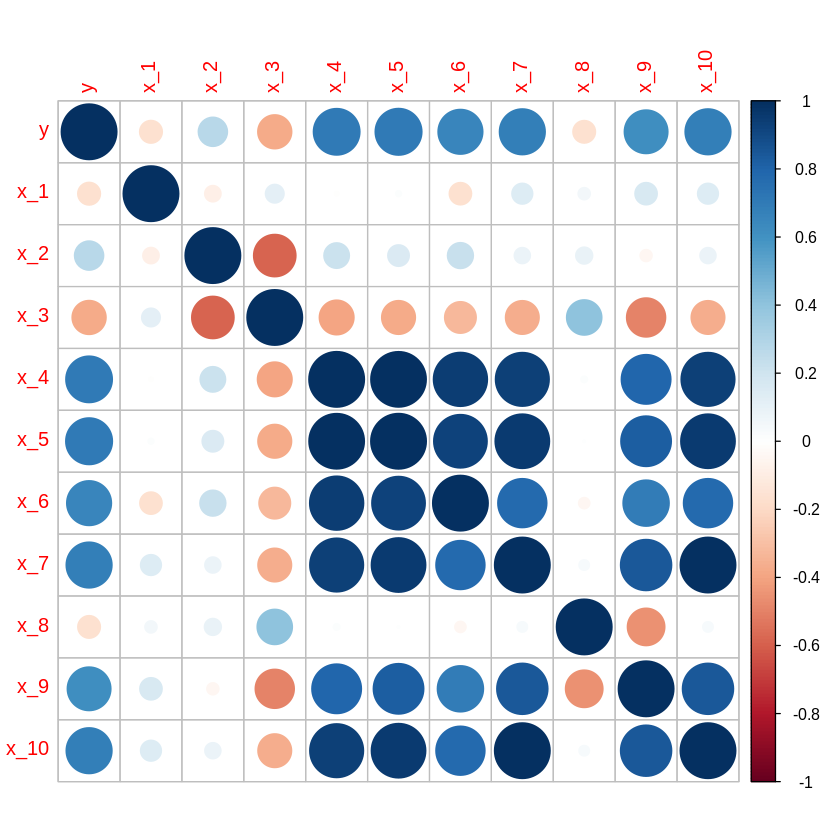

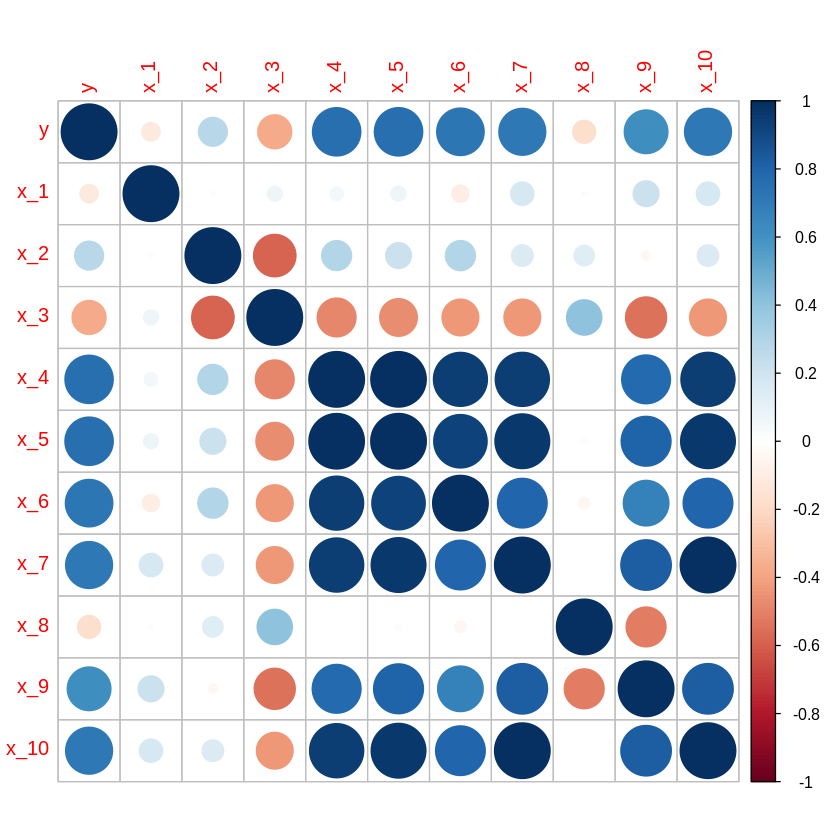

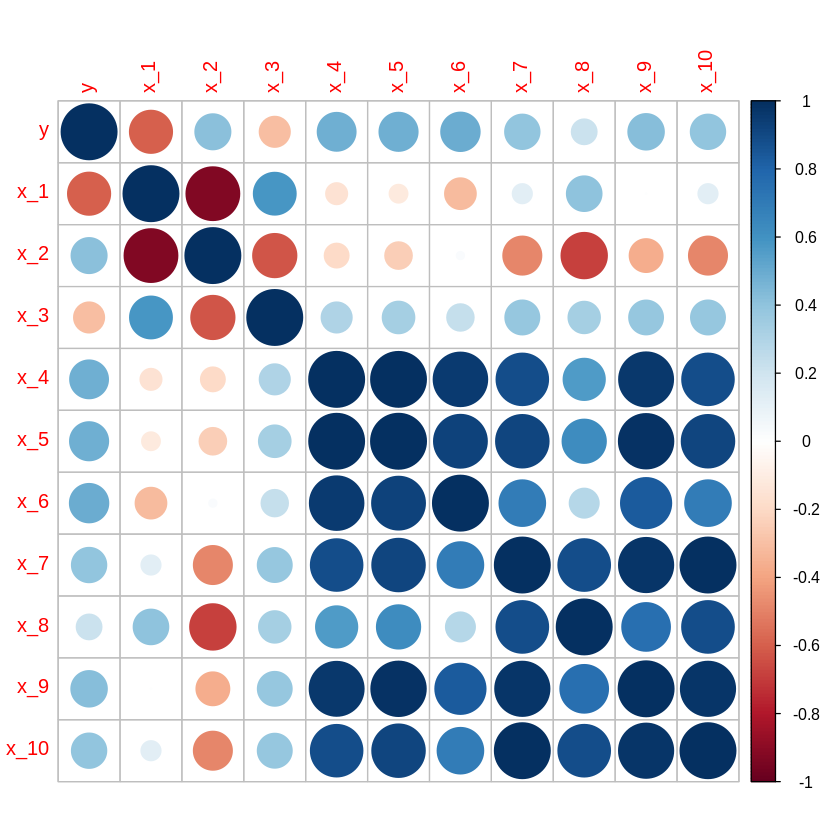

In [ ]:

corrplot(Cor2)
corrplot(Cor3)

# Fitting into Models

In [ ]:
test_data_precited <- test_data

Simple OLS Model & Summary

In [ ]:
ols_model <- lm(y ~ x_1+x_2+x_3+x_4+x_5+x_6+x_7+x_8+x_9+x_10, data = train_data)
summary(ols_model)



Call:
lm(formula = y ~ x_1 + x_2 + x_3 + x_4 + x_5 + x_6 + x_7 + x_8 + 
    x_9 + x_10, data = train_data)

Residuals:
    Min      1Q  Median      3Q     Max 
-1.8138 -0.6850  0.1717  0.4833  1.9544 

Coefficients: (2 not defined because of singularities)
              Estimate Std. Error t value Pr(>|t|)
(Intercept)  -9.120845  17.561559  -0.519    0.610
x_1          -0.855781   0.702727  -1.218    0.240
x_2           6.310018   4.263064   1.480    0.157
x_3           0.014215   0.009461   1.502    0.151
x_4          -0.770508   2.593885  -0.297    0.770
x_5           3.386685   3.643216   0.930    0.366
x_6          -1.479912   2.169645  -0.682    0.504
x_7                 NA         NA      NA       NA
x_8         -13.450969   8.700101  -1.546    0.140
x_9          -0.125294   0.246570  -0.508    0.618
x_10                NA         NA      NA       NA

Residual standard error: 1.208 on 17 degrees of freedom
Multiple R-squared:  0.7201,	Adjusted R-squared:  0.5883 
F-statistic: 5.

 Plotting Simple OLS (not required)

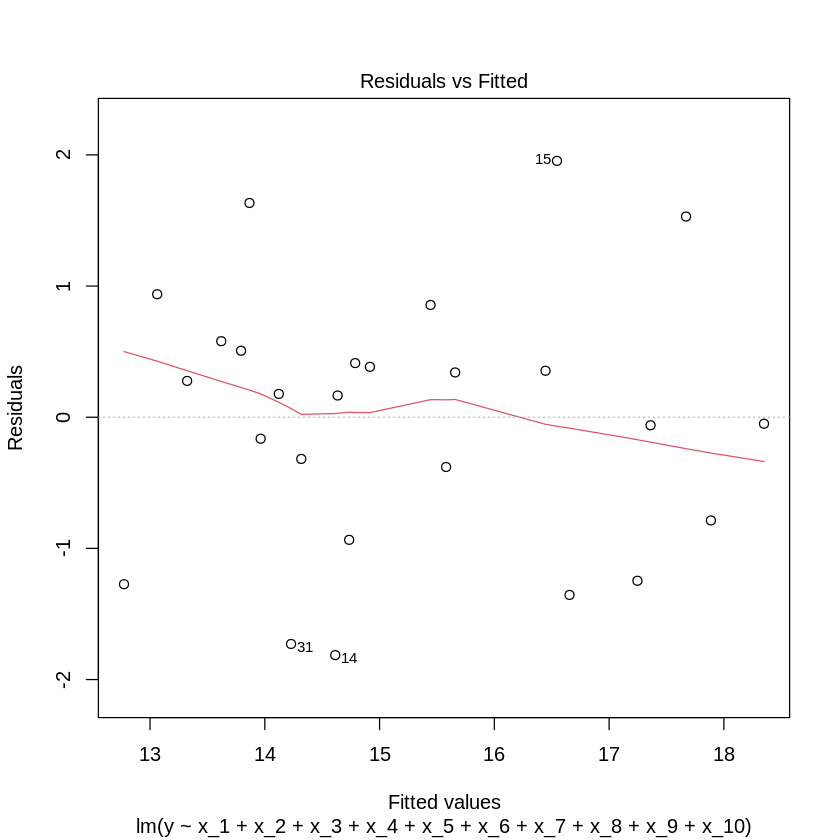

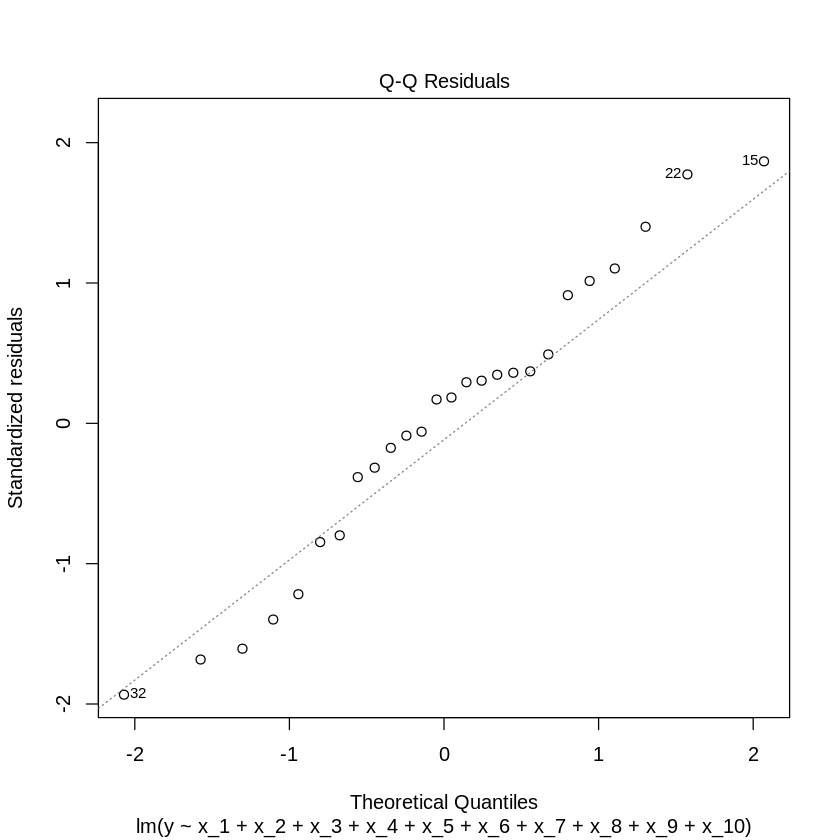

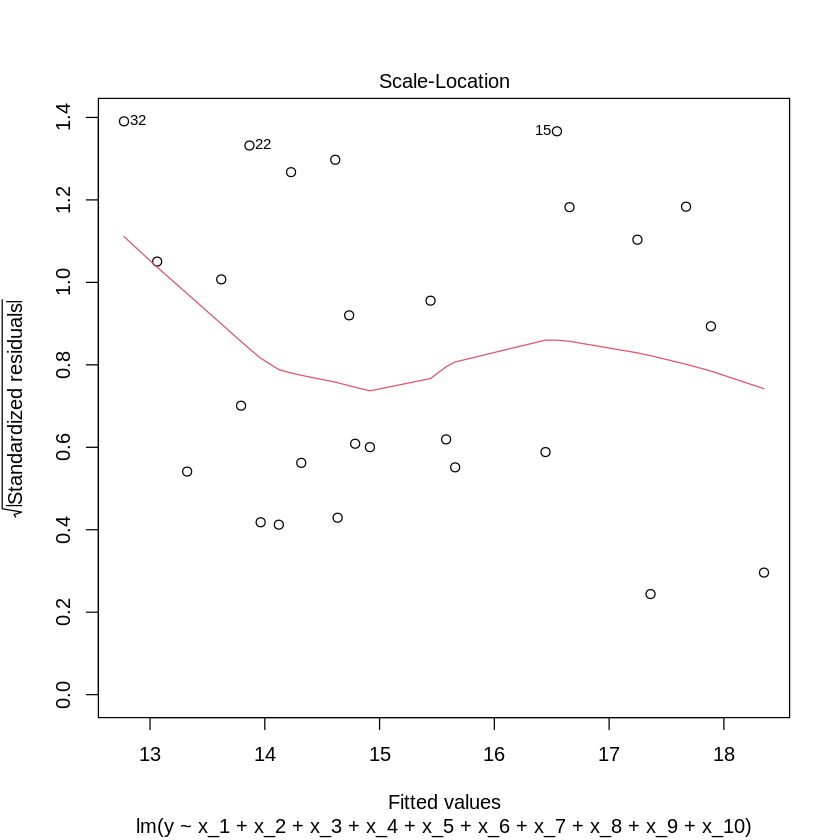

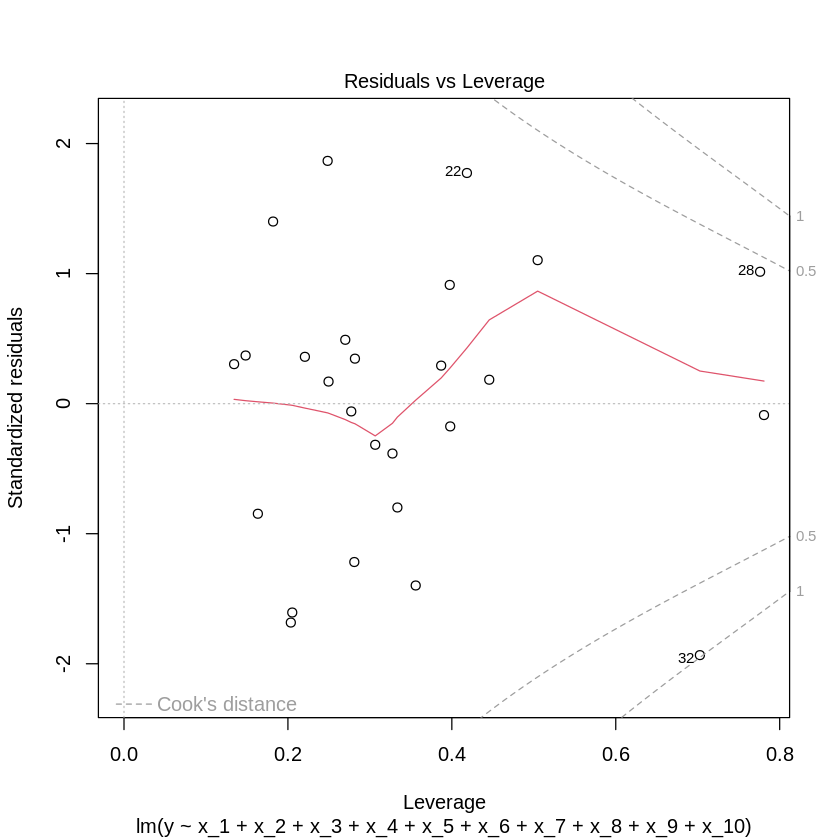

In [ ]:
par(mfrow = c(1,1))
plot(ols_model)  # Check residuals, leverage, and normality


In [ ]:
vif_scores <- vif(ols_model)
print(vif_scores)

ERROR: Error in vif.default(ols_model): there are aliased coefficients in the model


In [ ]:
var(train_data$x_7)

[1] 0.7625846

indentifying Singularity (Alias)

In [ ]:
alias(lm(y ~ ., data = train_data))

Model :
y ~ x_1 + x_2 + x_3 + x_4 + x_5 + x_6 + x_7 + x_8 + x_9 + x_10

Complete :
     (Intercept) x_1   x_2   x_3   x_4   x_5   x_6   x_8   x_9  
x_7      0           0     0     0     0     1    -1     0     0
x_10     0           0     0     0     0  1/50 -1/50     0     0


Remove linearly dependent variables

In [ ]:
train_data_cleaned <- train_data[, !apply(train_data, 2, function(x) all(x == x[1]))]
#print(train_data_cleaned)
ols_cleaned_model = lm(y ~ x_1+x_2+x_3+x_4+x_5+x_6+x_8+x_9, data = train_data_cleaned)
summary(ols_cleaned_model)


Call:
lm(formula = y ~ x_1 + x_2 + x_3 + x_4 + x_5 + x_6 + x_8 + x_9, 
    data = train_data_cleaned)

Residuals:
    Min      1Q  Median      3Q     Max 
-1.8138 -0.6850  0.1717  0.4833  1.9544 

Coefficients:
              Estimate Std. Error t value Pr(>|t|)
(Intercept)  -9.120845  17.561559  -0.519    0.610
x_1          -0.855781   0.702727  -1.218    0.240
x_2           6.310018   4.263064   1.480    0.157
x_3           0.014215   0.009461   1.502    0.151
x_4          -0.770508   2.593885  -0.297    0.770
x_5           3.386685   3.643216   0.930    0.366
x_6          -1.479912   2.169645  -0.682    0.504
x_8         -13.450969   8.700101  -1.546    0.140
x_9          -0.125294   0.246570  -0.508    0.618

Residual standard error: 1.208 on 17 degrees of freedom
Multiple R-squared:  0.7201,	Adjusted R-squared:  0.5883 
F-statistic: 5.466 on 8 and 17 DF,  p-value: 0.001612


In [ ]:
vif_values <- vif(ols_cleaned_model)  # Use OLS to check VIF
print(vif_values)

       x_1        x_2        x_3        x_4        x_5        x_6        x_8 
  2.149156   5.339411   4.983590 520.757328 424.374295  25.588846   8.639865 
       x_9 
 36.351670 


prediction based on cleaned OLS

In [ ]:
test_data_precited$predicted_y_olsModel2 <- predict(ols_cleaned_model, newdata = test_data)

Fitting OLS based on dataset after dropping outliers

In [ ]:
ols_outliersDropped_model = lm(y ~ x_1+x_2+x_3+x_4+x_5+x_6+x_7+x_8+x_9+x_10, data = train_data_removedOutliers)
summary(ols_outliersDropped_model)
ols_outliersDropped_model2 = lm(y ~ x_1+x_2+x_3+x_4+x_5+x_6+x_8+x_9, data = train_data_removedOutliers)
summary(ols_outliersDropped_model2)


Call:
lm(formula = y ~ x_1 + x_2 + x_3 + x_4 + x_5 + x_6 + x_7 + x_8 + 
    x_9 + x_10, data = train_data_removedOutliers)

Residuals:
    Min      1Q  Median      3Q     Max 
-1.6543 -0.4275 -0.0358  0.5970  1.7735 

Coefficients: (2 not defined because of singularities)
              Estimate Std. Error t value Pr(>|t|)  
(Intercept)   2.077758  18.863744   0.110   0.9139  
x_1          -0.124129   0.835945  -0.148   0.8841  
x_2           4.451546   4.442579   1.002   0.3333  
x_3           0.009551   0.009751   0.979   0.3440  
x_4          -1.657373   2.685038  -0.617   0.5470  
x_5           5.629507   4.050116   1.390   0.1862  
x_6          -1.925880   2.191682  -0.879   0.3944  
x_7                 NA         NA      NA       NA  
x_8         -21.929684  10.349872  -2.119   0.0525 .
x_9          -0.361654   0.285718  -1.266   0.2263  
x_10                NA         NA      NA       NA  
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard erro


Call:
lm(formula = y ~ x_1 + x_2 + x_3 + x_4 + x_5 + x_6 + x_8 + x_9, 
    data = train_data_removedOutliers)

Residuals:
    Min      1Q  Median      3Q     Max 
-1.6543 -0.4275 -0.0358  0.5970  1.7735 

Coefficients:
              Estimate Std. Error t value Pr(>|t|)  
(Intercept)   2.077758  18.863744   0.110   0.9139  
x_1          -0.124129   0.835945  -0.148   0.8841  
x_2           4.451546   4.442579   1.002   0.3333  
x_3           0.009551   0.009751   0.979   0.3440  
x_4          -1.657373   2.685038  -0.617   0.5470  
x_5           5.629507   4.050116   1.390   0.1862  
x_6          -1.925880   2.191682  -0.879   0.3944  
x_8         -21.929684  10.349872  -2.119   0.0525 .
x_9          -0.361654   0.285718  -1.266   0.2263  
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 1.194 on 14 degrees of freedom
Multiple R-squared:  0.7364,	Adjusted R-squared:  0.5858 
F-statistic:  4.89 on 8 and 14 DF,  p-value: 0.004848


In [ ]:
vif_values_withoutOutliers <- vif(ols_outliersDropped_model2)  # Use OLS to check VIF
print(vif_values_withoutOutliers)

       x_1        x_2        x_3        x_4        x_5        x_6        x_8 
  2.685210   5.425984   5.374496 532.973287 496.835594  25.441600  10.908487 
       x_9 
 45.957625 


In [ ]:
test_data_precited$predicted_y_OutlierDroppedModel <- predict(ols_outliersDropped_model2, newdata = test_data)

Both-way Stepwise regession model and summary

In [ ]:
both_model <- step(ols_model, direction = "both", trace = 0)
summary(both_model)


Call:
lm(formula = y ~ x_1 + x_2 + x_3 + x_5 + x_8, data = train_data)

Residuals:
     Min       1Q   Median       3Q      Max 
-1.92704 -0.48727 -0.07742  0.56145  2.35927 

Coefficients:
             Estimate Std. Error t value Pr(>|t|)    
(Intercept) -7.724561   9.883837  -0.782   0.4436    
x_1         -0.768065   0.470100  -1.634   0.1179    
x_2          5.336196   2.591570   2.059   0.0527 .  
x_3          0.013476   0.007299   1.846   0.0797 .  
x_5          1.202803   0.202741   5.933  8.4e-06 ***
x_8         -8.593010   3.762480  -2.284   0.0334 *  
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 1.163 on 20 degrees of freedom
Multiple R-squared:  0.6947,	Adjusted R-squared:  0.6184 
F-statistic: 9.101 on 5 and 20 DF,  p-value: 0.0001227


In [ ]:
vif_scores <- vif(both_model)
print(vif_scores)

     x_1      x_2      x_3      x_5      x_8 
1.037448 2.128465 3.199896 1.417595 1.743001 


In [ ]:
test_data_precited$predicted_y_bothModel <- predict(both_model, newdata = test_data)

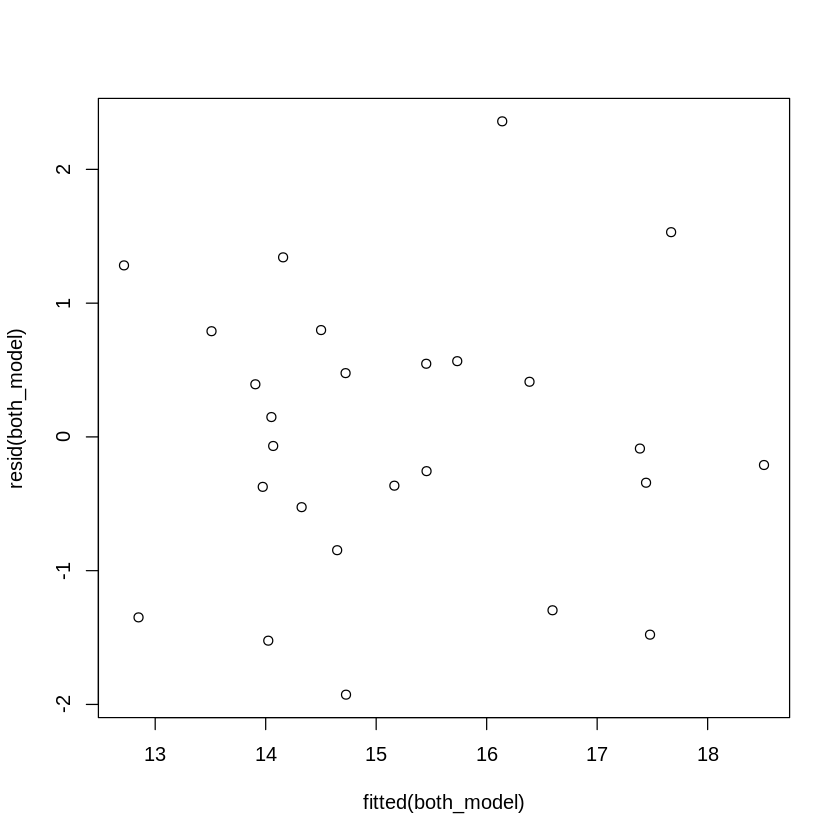

In [ ]:
plot(fitted(both_model), resid(both_model))  # Should look like a cloud, not a fan

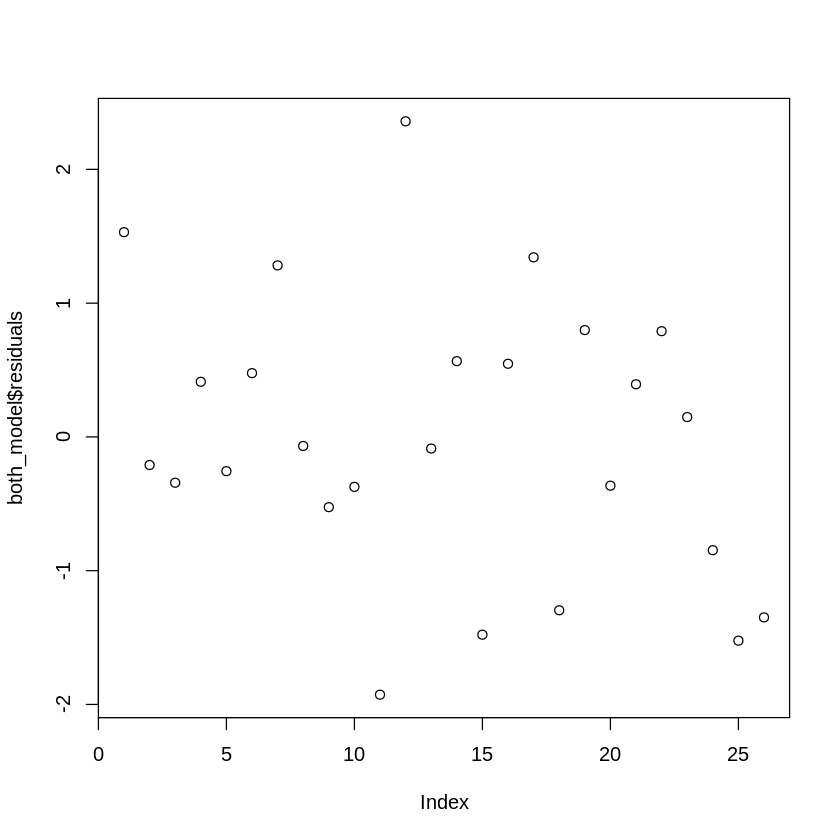

In [ ]:
plot(both_model$residuals)

Robust regression Model based on Hubers loss

In [ ]:
robust_model <- rlm(y ~ x_1+x_2+x_3+x_4+x_5+x_6+x_8+x_9, data = train_data, psi = psi.huber)

# Summary of robust model
summary(robust_model)



Call: rlm(formula = y ~ x_1 + x_2 + x_3 + x_4 + x_5 + x_6 + x_8 + x_9, 
    data = train_data, psi = psi.huber)
Residuals:
    Min      1Q  Median      3Q     Max 
-2.0143 -0.6068  0.1272  0.4721  2.2530 

Coefficients:
            Value    Std. Error t value 
(Intercept)  -8.2084  19.4618    -0.4218
x_1          -0.9339   0.7788    -1.1992
x_2           6.1926   4.7243     1.3108
x_3           0.0149   0.0105     1.4258
x_4          -0.4763   2.8746    -0.1657
x_5           2.8197   4.0374     0.6984
x_6          -1.4506   2.4044    -0.6033
x_8         -14.5551   9.6415    -1.5096
x_9          -0.1134   0.2732    -0.4151

Residual standard error: 0.7845 on 17 degrees of freedom

In [ ]:
vif_robust_scores <- vif(robust_model)
print(vif_robust_scores)

       x_1        x_2        x_3        x_4        x_5        x_6        x_8 
  2.149156   5.339411   4.983590 520.757328 424.374295  25.588846   8.639865 
       x_9 
 36.351670 


In [ ]:
# Predict on Test Data
test_data_precited$predicted_y_robust_huber <- predict(robust_model, newdata = test_data)

Robust regression Model based on MM Method

In [ ]:
robust_model_singular <- lmrob(y ~ x_1+x_2+x_3+x_4+x_5+x_6+x_7+x_8+x_9+x_10, data = train_data, method = "MM")
summary(robust_model_singular)


Call:
lmrob(formula = y ~ x_1 + x_2 + x_3 + x_4 + x_5 + x_6 + x_7 + x_8 + x_9 + 
    x_10, data = train_data, method = "MM")
 \--> method = "MM"
Residuals:
    Min      1Q  Median      3Q     Max 
-4.8231 -0.5730  0.1021  0.3658  2.2518 

Coefficients: (2 not defined because of singularities)
             Estimate Std. Error t value Pr(>|t|)  
(Intercept) -7.609163   9.845506  -0.773   0.4502  
x_1         -0.581110   0.819926  -0.709   0.4881  
x_2          4.617232   2.616750   1.764   0.0956 .
x_3          0.008216   0.009920   0.828   0.4190  
x_4         -2.086893   1.959675  -1.065   0.3018  
x_5          4.093641   2.234675   1.832   0.0845 .
x_6         -0.190132   1.629617  -0.117   0.9085  
x_7                NA         NA      NA       NA  
x_8          4.706334  12.711890   0.370   0.7158  
x_9          0.080280   0.166883   0.481   0.6366  
x_10               NA         NA      NA       NA  
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Robust residu

In [ ]:
robust_model2 <- lmrob(y ~ x_1+x_2+x_3+x_4+x_5+x_6+x_8+x_9, data = train_data, method = "MM")
summary(robust_model2)


Call:
lmrob(formula = y ~ x_1 + x_2 + x_3 + x_4 + x_5 + x_6 + x_8 + x_9, data = train_data, 
    method = "MM")
 \--> method = "MM"
Residuals:
    Min      1Q  Median      3Q     Max 
-4.8231 -0.5730  0.1021  0.3658  2.2518 

Coefficients:
             Estimate Std. Error t value Pr(>|t|)  
(Intercept) -7.609163   9.845506  -0.773   0.4502  
x_1         -0.581110   0.819926  -0.709   0.4881  
x_2          4.617232   2.616750   1.764   0.0956 .
x_3          0.008216   0.009920   0.828   0.4190  
x_4         -2.086893   1.959675  -1.065   0.3018  
x_5          4.093641   2.234675   1.832   0.0845 .
x_6         -0.190132   1.629617  -0.117   0.9085  
x_8          4.706333  12.711890   0.370   0.7158  
x_9          0.080280   0.166883   0.481   0.6366  
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Robust residual standard error: 1.003 
Multiple R-squared:  0.7278,	Adjusted R-squared:  0.5997 
Convergence in 18 IRWLS iterations

Robustness weights: 
 observation 26 i

In [ ]:
vif_robust_scores2 <- vif(robust_model2)
print(vif_robust_scores2)

ERROR: Error: object 'robust_model2' not found


In [ ]:
test_data_precited$predicted_y_robust_MM <- predict(robust_model2, newdata = test_data)

Printing Test Dataset with all predictions

In [ ]:
print(test_data)

      y x_1  x_2 x_3   x_4  x_5  x_6  x_7  x_8 x_9  x_10
4  17.3   0 3.86  99 12.85 7.70 3.90 3.80 0.35  22 0.076
6  16.5   0 3.85  61 10.30 6.20 2.50 3.70 0.38  20 0.074
7  15.8   0 3.93  66  4.90 2.75 1.20 1.55 0.29  11 0.031
18 16.3   1 3.76  77  8.35 5.05 1.90 3.15 0.37  17 0.063
21 15.7   1 3.75 120  8.80 5.50 1.85 3.65 0.39  19 0.073
29 14.0   1 3.76 104  8.70 5.10 2.25 2.85 0.34  17 0.057


In [ ]:
print(test_data_precited)

      y x_1  x_2 x_3   x_4  x_5  x_6  x_7  x_8 x_9  x_10 predicted_y_olsModel2
4  17.3   0 3.86  99 12.85 7.70 3.90 3.80 0.35  22 0.076              19.58356
6  16.5   0 3.85  61 10.30 6.20 2.50 3.70 0.38  20 0.074              17.78401
7  15.8   0 3.93  66  4.90 2.75 1.20 1.55 0.29  11 0.031              15.09868
18 16.3   1 3.76  77  8.35 5.05 1.90 3.15 0.37  17 0.063              15.59390
21 15.7   1 3.75 120  8.80 5.50 1.85 3.65 0.39  19 0.073              16.87370
29 14.0   1 3.76 104  8.70 5.10 2.25 2.85 0.34  17 0.057              15.76292
   predicted_y_OutlierDroppedModel       s1 predicted_y_bothModel
4                         20.03193 18.32826              20.46131
6                         17.41289 17.38488              17.83387
7                         14.01295 14.35266              14.95184
18                        15.56706 16.02721              15.50387
21                        17.09276 16.23087              16.39938
29                        14.95171 15.88514        

In [ ]:
names(test_data_precited)

[1] "y"                               "x_1"                            
 [3] "x_2"                             "x_3"                            
 [5] "x_4"                             "x_5"                            
 [7] "x_6"                             "x_7"                            
 [9] "x_8"                             "x_9"                            
[11] "x_10"                            "predicted_y_olsModel2"          
[13] "predicted_y_OutlierDroppedModel" "predicted_afterL2"              
[15] "predicted_y_bothModel"           "predicted_y_robust_huber"       
[17] "predicted_y_robust_MM"

might not be necessary


In [ ]:
# List of prediction column names
prediction_columns <- c(
  "predicted_y_olsModel2",
  "predicted_y_OutlierDroppedModel",
  "predicted_y_bothModel",
  "predicted_y_robust_huber",
  "predicted_y_robust_MM"
)

# Function to compute RMSE and R²
evaluate_model <- function(pred_column) {
  predicted <- test_data_precited[[pred_column]]
  rmse <- sqrt(mean((actuals - predicted)^2))
  r_squared <- cor(actuals, predicted)^2
  return(c(RMSE = rmse, R_squared = r_squared))
}

# Apply the function to each model
results <- sapply(prediction_columns, evaluate_model)

# Transpose for readability (models as rows)
results <- t(results)
print(results)

#Model Evaluation

Evaluation of OLS Model

In [ ]:
actuals <- test_data_precited$y
predicted_ols <- test_data_precited$predicted_y_olsModel2

# Compute RMSE and R² for Robust Model
rmse_ols <- sqrt(mean((actuals - predicted_ols)^2))
r_squared_ols <- cor(actuals, predicted_ols)^2

Evaluation of Outliers Dropped OLS Model

In [ ]:
predicted_ols2 <- test_data_precited$predicted_y_OutlierDroppedModel

# Compute RMSE and R² for Robust Model
rmse_ols_outliers <- sqrt(mean((actuals - predicted_ols2)^2))
r_squared_ols_outliers <- cor(actuals, predicted_ols2)^2

Evaluation of Both Way Model

In [ ]:
predicted_both <- test_data_precited$predicted_y_bothModel

# Compute RMSE and R² for Robust Model
rmse_both <- sqrt(mean((actuals - predicted_both)^2))
r_squared_both <- cor(actuals, predicted_both)^2


Evaluation of Robust Model

In [ ]:
actuals <- test_data$y
predicted_robust <- test_data_precited$predicted_y_robust_huber

rss<- sum((actuals - predicted_robust)^2)
rmse_robust3 <- sqrt(mean((actuals - predicted_robust)^2))
r_squared_robust3 <- cor(actuals, predicted_robust)^2

In [ ]:
actuals <- test_data$y
predicted_robust2 <- test_data_precited$predicted_y_robust_MM

rss2<- sum((actuals - predicted_robust2)^2)
rmse_robust2 <- sqrt(mean((actuals - predicted_robust2)^2))
r_squared_robust2 <- cor(actuals, predicted_robust2)^2

Evaluation of L2 Model


#Comparison

In [ ]:
def adjusted_r_squared(r_squared, n, p):
    """
    Calculate Adjusted R^2 from R^2, number of observations (n), and predictors (p)

    Parameters:
    - r_squared (float): R² value from regression
    - n (int): Number of observations (data points)
    - p (int): Number of predictors (independent variables)

    Returns:
    - float: Adjusted R²
    """
    if n <= p + 1:
        raise ValueError("Number of observations must be greater than number of predictors + 1")

    return 1 - (1 - r_squared) * (n - 1) / (n - p - 1)

# Example usage
r2 = 0.85
n = 100  # number of samples
p = 5    # number of predictors

adj_r2 = adjusted_r_squared(r2, n, p)
print("Adjusted R^2:", adj_r2)

In [ ]:
cat("OLS Regression RMSE:", rmse_ols, "\n")
cat("OLS Regression R²:", r_squared_ols, "\n")
print("___________________________________________")
cat("OLS Regression RMSE (Without Outliers):", rmse_ols_outliers, "\n")
cat("OLS Regression R² (Without Outliers):", r_squared_ols_outliers, "\n")
print("___________________________________________")
cat("Step-Wise (both-way) Regression RMSE:", rmse_both, "\n")
cat("Step-Wise (both-way) Regression R²:", r_squared_both, "\n")
print("___________________________________________")
#cat("Robust (huber) Regression RSS:", rss, "\n")
cat("Robust (huber) Regression RMSE:", rmse_robust3, "\n")
cat("Robust (huber) Regression R²:", r_squared_robust3, "\n")
print("___________________________________________")
#cat("Robust (MM) Regression RSS:", rss2, "\n")
cat("Robust (MM) Regression RMSE:", rmse_robust2, "\n")
cat("Robust (MM) Regression R²:", r_squared_robust2, "\n")

OLS Regression RMSE: 1.434063 
OLS Regression R²: 0.4337381 
[1] "___________________________________________"
OLS Regression RMSE (Without Outliers): 1.574437 
OLS Regression R² (without Outliers): 0.4730675 
[1] "___________________________________________"
Step-Wise (both-way) Regression RMSE: 1.750833 
Step-Wise (both-way) Regression R²: 0.3585757 
[1] "___________________________________________"
L2 Regression RMSE: 1.143469 
L2 Regression R²: 0.333732 
[1] "___________________________________________"
Robust (huber) Regression RMSE: 1.378922 
Robust (huber) Regression R²: 0.4351121 
[1] "___________________________________________"
Robust (MM) Regression RMSE: 1.246141 
Robust (MM) Regression R²: 0.3723232 


#JUNK CODE

Removing outliers (Not requied)

In [ ]:
remove_outliers_boxplot <- function(df) {
  for (col in colnames(df)) {
    if (is.numeric(df[[col]])) {
      outliers <- boxplot.stats(df[[col]])$out  # Identify outliers
      df <- df[!df[[col]] %in% outliers, ]  # Remove outliers
    }
  }
  return(df)
}